# Big Data Visualization Portfolio: European SME Financing Pain Index

**Research question:** Can a borrower-side SME Financing Pain Index reveal credit stress that is not fully captured by market-side stress indicators such as the ECB CISS?

This notebook does not simply load pre-rendered PNG files. It reads the processed data and generates the visualizations directly with `pandas`, `seaborn`, and `matplotlib`.

In [26]:
from pathlib import Path
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from IPython.display import HTML, display


def find_project_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data" / "processed" / "sme_fpi_panel.csv").exists():
            return candidate
        nested = candidate / "SME_FPI"
        if (nested / "data" / "processed" / "sme_fpi_panel.csv").exists():
            return nested
    raise FileNotFoundError("Could not locate the SME_FPI project root.")


BASE = find_project_root()
PROCESSED = BASE / "data" / "processed"
REPORTS = BASE / "reports"
NOTEBOOK_FIGURES = BASE / "figures" / "notebook_generated"
NOTEBOOK_FIGURES.mkdir(parents=True, exist_ok=True)

panel = pd.read_csv(PROCESSED / "sme_fpi_panel.csv")
df = panel.copy()
loadings = pd.read_csv(PROCESSED / "pca_loadings.csv")
explained = pd.read_csv(PROCESSED / "pca_explained_variance.csv")
profiles = pd.read_csv(PROCESSED / "sme_fpi_cluster_profiles.csv")
weights = pd.read_csv(PROCESSED / "weighting_comparison.csv")
sensitivity = pd.read_csv(PROCESSED / "index_sensitivity_summary.csv")
cluster_validation = pd.read_csv(PROCESSED / "cluster_validation_diagnostics.csv")
validation_results = pd.read_csv(PROCESSED / "validation_results.csv")
validation_panel = pd.read_csv(PROCESSED / "external_validation_panel.csv")
variable_candidates = pd.read_csv(PROCESSED / "variable_expansion_candidates.csv")
big_review = pd.read_csv(PROCESSED / "big_cube_review_summary.csv")
safe_long = pd.read_csv(PROCESSED / "safe_component_long.csv")
size_summary = pd.read_csv(PROCESSED / "sector_size_component_summary.csv")
severity_cube = pd.read_csv(PROCESSED / "safe_problem_severity_cube.csv")
access_cube = pd.read_csv(PROCESSED / "access_finance_severity_cube.csv")

print(f"Project root: {BASE}")
print(f"Main analytical panel: {panel.shape[0]:,} rows x {panel.shape[1]:,} columns")
print(f"Big SAFE Q0B cube summary is loaded from: {PROCESSED / 'big_cube_review_summary.csv'}")
display(panel.head())

Project root: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI
Main analytical panel: 386 rows x 44 columns
Big SAFE Q0B cube summary is loaded from: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\data\processed\big_cube_review_summary.csv


,REF_AREA,country_name,TIME_PERIOD,period_sort,access_finance_main_problem,bank_loan_cost_too_high,bank_loan_limited_amount,bank_loan_rejected,bank_willingness_deteriorated,interest_rates_increased,...,cluster,cluster_name,CISS_mean,CISS_max,CISS_z,Hidden_SME_Stress,Relative_Gap_equal,Relative_Gap_fixed_baseline,Relative_Gap_pca_weighted,Relative_Gap_reliability_weighted
0,AT,Austria,2009-S1,20091,9.163446,4.920178,NaN,6.161737,26.82178,13.07885,...,1,Bank Loan Cost Too High driven stress,0.742533,0.909008,3.356298,-3.369617,-3.369617,-2.329493,-3.401125,-3.381550
1,AT,Austria,2009-S2,20092,6.478622,8.266948,NaN,14.313510,25.69492,16.35983,...,1,Bank Loan Cost Too High driven stress,0.362614,0.625042,1.132756,-0.523938,-0.523938,0.940593,-0.766769,-0.803431
2,AT,Austria,2010-S1,20101,7.910672,0.000000,4.777519,3.293514,21.95452,22.11973,...,2,Low SME financing pain,0.299099,0.620198,0.761023,-1.461009,-1.461009,-0.734846,-1.333318,-1.296933
3,AT,Austria,2010-S2,20102,8.260863,0.000000,4.053249,1.901498,22.08682,44.26475,...,2,Low SME financing pain,0.354145,0.519761,1.083188,-1.617500,-1.617500,-0.252617,-1.560985,-1.534308
4,AT,Austria,2011-S1,20111,7.343262,1.408845,5.749412,0.000000,28.59319,53.05953,...,0,Interest Rates Increased driven stress,0.241446,0.348983,0.423593,-0.624121,-0.624121,1.233069,-0.647016,-0.625039


## Course Requirement Check

- **Submission format:** this is a `.ipynb` notebook with executable code, saved outputs, and written comments.
- **Tool requirement:** the notebook uses Python with `pandas`, `matplotlib`, `seaborn`, and `plotly`.
- **One research question:** all figures support the same question about borrower-side SME financing pain versus the ECB CISS market-stress benchmark.
- **Small portfolio logic:** the six core portfolio figures are the time-series comparison, country-period heatmap, latest relative-gap ranking, PCA validation figure, PCA cluster-regime figure, and Big Data cube severity heatmap. The other figures are optional diagnostics that support interpretation, robustness, or general-audience communication.
- **Design rationale:** each visualization has a short bullet-point explanation below it covering chart choice, interpretation, and potential limitations.

## Analytical Story

This project follows one storyline:

```text
Problem -> Hypotheses -> Model -> Validation -> Visual Insights -> Limitations
```

**Problem:** market-side indicators can show whether financial markets are stressed, but they may miss financing pain reported directly by SMEs.

**Hypotheses**

- **H1: Common factor hypothesis.** SAFE borrower-side financing variables share one broad financing-pain dimension.
- **H2: Benchmark-gap hypothesis.** SME_FPI does not always move together with CISS because the two indicators measure different sides of stress.
- **H3: Heterogeneity hypothesis.** SME financing pain differs by country, period, firm size, and problem type.

**Model:** six SAFE borrower-side variables are standardized, averaged into SME_FPI, and compared with the common ECB CISS benchmark.

**Validation:** PCA, correlation analysis, clustering, and distribution checks test whether the index behaves like a coherent multidimensional measure.

**Visual insights:** the core portfolio uses six main figures; the remaining figures are diagnostics or dashboard-ready extensions.

**Limitations:** the index is descriptive, survey-based, and not a causal model. The CISS gap is a relative benchmark gap, not direct proof of local financial-market stress.

## 1. Dataset Description

All datasets in this project are **tabular data**. This means they are organized like a spreadsheet, with rows as observations and columns as variables.

- **Main analytical dataset:** `sme_fpi_panel.csv`
  - 386 rows x 28 columns
  - Each row represents one country in one half-year period, for example Germany in 2020 H1.
  - This dataset is used to calculate SME_FPI, compare it with CISS, run PCA, and create financing-regime clusters.

- **Big Data dataset:** ECB SAFE Q0B Pressingness Cube
  - 231,231 rows x 33 columns
  - This is a high-dimensional survey cube with country, period, firm size, sector, firm age, problem type, answer level, and weighted response values.
  - This dataset is used for the Big Data Visualization part and additional diagnostic analysis.

In short, the **386-row panel** is the compact analytical layer used to build the SME_FPI index, while the **231,231-row SAFE Q0B cube** is the larger multidimensional layer used for Big Data Visualization and supporting diagnostics.

In [27]:
main_dataset = pd.DataFrame(
    [
        {
            "dataset": "Main analytical panel",
            "file": "sme_fpi_panel.csv",
            "rows": len(panel),
            "columns": panel.shape[1],
            "role": "SME_FPI index, CISS comparison, PCA, clustering",
        },
        {
            "dataset": "Selected SAFE component long data",
            "file": "safe_component_long.csv",
            "rows": len(safe_long),
            "columns": safe_long.shape[1],
            "role": "Original selected financing-pain survey components",
        },
        {
            "dataset": "SAFE Q0B big cube",
            "file": "safe_q0b_pressingness_big_cube.csv",
            "rows": int(big_review.loc[0, "raw_rows"]),
            "columns": int(big_review.loc[0, "raw_columns"]),
            "role": "Big Data Visualization and additional diagnostics",
        },
        {
            "dataset": "Problem severity cube",
            "file": "safe_problem_severity_cube.csv",
            "rows": len(severity_cube),
            "columns": severity_cube.shape[1],
            "role": "Severity score and severe-response shares by country, period, firm group, problem",
        },
    ]
)

display(main_dataset)

missing_check = panel[
    ["SME_FPI_equal_z", "CISS_z", "Hidden_SME_Stress", "components_available"]
].isna().sum().rename("missing_values").to_frame()
display(missing_check)

,dataset,file,rows,columns,role
0,Main analytical panel,sme_fpi_panel.csv,386,44,"SME_FPI index, CISS comparison, PCA, clustering"
1,Selected SAFE component long data,safe_component_long.csv,11300,37,Original selected financing-pain survey compon...
2,SAFE Q0B big cube,safe_q0b_pressingness_big_cube.csv,231231,33,Big Data Visualization and additional diagnostics
3,Problem severity cube,safe_problem_severity_cube.csv,20570,13,Severity score and severe-response shares by c...


,missing_values
SME_FPI_equal_z,0
CISS_z,0
Hidden_SME_Stress,0
components_available,0


## 2. What Are SAFE and CISS?

**SAFE** stands for the ECB Survey on the Access to Finance of Enterprises. It asks firms about financing conditions, such as loan rejection, rising interest rates, banks' willingness to lend, and access-to-finance problems. In this project, SAFE captures the financing pain reported directly by firms.

**CISS** is the ECB Composite Indicator of Systemic Stress. It measures stress in financial markets. In this project, CISS is not a country-specific SME variable. It is used only as a common euro-area market-stress benchmark.

Plain-language version: CISS is like a financial-market stress thermometer for the euro area; higher values mean financial markets are under more pressure.

The key comparison is:

- SAFE-based SME_FPI: borrower-side financing pain reported by firms
- ECB CISS: market-side systemic stress benchmark

These two indicators do not measure the same thing. They show two different perspectives on financial stress.

## 3. SME_FPI Index Formula

SME_FPI is built from six borrower-side SME financing-pain variables. All six variables are coded so that higher values mean greater financing pain.

**Step 1. Standardize each component**

$$
z(x_{i,c,t}) = \frac{x_{i,c,t} - \mu_i}{\sigma_i}
$$

**Step 2. Average the available standardized components**

$$
SME\_FPI\_{raw}(c,t) = \frac{1}{|I(c,t)|}\sum_{i \in I(c,t)} z(x_{i,c,t})
$$

The index is calculated only when at least four components are available.

**Step 3. Standardize the raw index**

$$
SME\_FPI(c,t) = z(SME\_FPI\_{raw}(c,t))
$$

**Step 4. Compare it with the CISS benchmark**

$$
Hidden\_SME\_Stress(c,t) = SME\_FPI(c,t) - CISS_z(t)
$$

This gap is not a direct country-specific market-stress measure. It is a relative difference showing whether borrower-side SME financing pain is high compared with the common CISS benchmark.

In [28]:
component_vars = [
    "access_finance_main_problem",
    "bank_loan_rejected",
    "bank_loan_cost_too_high",
    "bank_loan_limited_amount",
    "bank_willingness_deteriorated",
    "interest_rates_increased",
]

component_table = pd.DataFrame(
    {
        "variable": component_vars,
        "plain_language_meaning": [
            "Share of SMEs saying access to finance is their most pressing problem",
            "Share of SMEs whose bank loan application was rejected",
            "Share of SMEs refusing a loan offer because the cost was too high",
            "Share of SMEs receiving only a limited loan amount",
            "Share of SMEs saying banks' willingness to lend deteriorated",
            "Share of SMEs saying interest rates increased",
        ],
        "direction": ["higher = more financing pain"] * 6,
    }
)

display(component_table)

formula_summary = pd.DataFrame(
    {
        "step": [
            "1. Standardize each component",
            "2. Average available components",
            "3. Standardize the raw average",
            "4. Compare with CISS benchmark",
        ],
        "formula": [
            "z(x_i,c,t) = (x_i,c,t - mean(x_i)) / sd(x_i)",
            "SME_FPI_raw(c,t) = mean of available z-scored components, requiring at least 4",
            "SME_FPI(c,t) = z(SME_FPI_raw(c,t))",
            "Hidden_SME_Stress(c,t) = SME_FPI(c,t) - CISS_z(t)",
        ],
    }
)

display(formula_summary)

,variable,plain_language_meaning,direction
0,access_finance_main_problem,Share of SMEs saying access to finance is thei...,higher = more financing pain
1,bank_loan_rejected,Share of SMEs whose bank loan application was ...,higher = more financing pain
2,bank_loan_cost_too_high,Share of SMEs refusing a loan offer because th...,higher = more financing pain
3,bank_loan_limited_amount,Share of SMEs receiving only a limited loan am...,higher = more financing pain
4,bank_willingness_deteriorated,Share of SMEs saying banks' willingness to len...,higher = more financing pain
5,interest_rates_increased,Share of SMEs saying interest rates increased,higher = more financing pain


,step,formula
0,1. Standardize each component,"z(x_i,c,t) = (x_i,c,t - mean(x_i)) / sd(x_i)"
1,2. Average available components,"SME_FPI_raw(c,t) = mean of available z-scored ..."
2,3. Standardize the raw average,"SME_FPI(c,t) = z(SME_FPI_raw(c,t))"
3,4. Compare with CISS benchmark,"Hidden_SME_Stress(c,t) = SME_FPI(c,t) - CISS_z(t)"


## 4. Plotting Code

The next cell contains the actual plotting code used in this notebook. The following figures are generated directly from the data rather than loaded from existing PNG files.

In [29]:
START_PERIOD = "2015-S1"

INK = "#172033"
MUTED = "#64748b"
GRID = "#e5e7eb"
TEAL = "#147c78"
RED = "#a33a2a"
GOLD = "#d99a1e"
PURPLE = "#7663a6"
SLATE = "#475569"

COMPONENT_LABELS = {
    "access_finance_main_problem": "Access to finance\nmain problem",
    "bank_loan_rejected": "Loan\nrejected",
    "bank_loan_cost_too_high": "Cost too\nhigh",
    "bank_loan_limited_amount": "Limited\namount",
    "bank_willingness_deteriorated": "Bank willingness\ndeteriorated",
    "interest_rates_increased": "Interest rates\nincreased",
}


def setup_style():
    mpl.rcParams.update(
        {
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "axes.edgecolor": "#d1d5db",
            "axes.labelcolor": INK,
            "xtick.color": INK,
            "ytick.color": INK,
            "font.family": "DejaVu Sans",
            "font.size": 10,
            "axes.titlesize": 13,
            "axes.titleweight": "bold",
            "axes.labelsize": 10,
            "legend.fontsize": 9,
            "axes.grid": False,
            "savefig.facecolor": "white",
        }
    )


def period_sort(period: str) -> int:
    return int(period[:4]) * 10 + int(period[-1])


def filter_periods(data: pd.DataFrame, start_period: str = START_PERIOD) -> pd.DataFrame:
    return data[data["period_sort"] >= period_sort(start_period)].copy()


def clean_axes(ax, grid_axis: str = "y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#d1d5db")
    ax.spines["bottom"].set_color("#d1d5db")
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)


def add_source_note(fig, text="Source: ECB SAFE and ECB CISS; calculations by author."):
    fig.text(0.01, 0.01, text, ha="left", va="bottom", fontsize=8, color=MUTED)


def show_and_save(fig, filename: str):
    out = NOTEBOOK_FIGURES / filename
    fig.savefig(out, dpi=220, bbox_inches="tight", pad_inches=0.18)
    display(fig)
    plt.close(fig)
    print(f"Saved notebook-generated figure: {out}")


def add_period_ticks(ax, periods, step=2):
    locs = np.arange(len(periods))
    labels = [p.replace("-S", " H") for p in periods]
    ax.set_xticks(locs[::step])
    ax.set_xticklabels([labels[i] for i in locs[::step]], rotation=0, ha="center")


setup_style()


def plot_signature(panel, big_review):
    p = filter_periods(panel)
    periods = sorted(p["TIME_PERIOD"].unique(), key=period_sort)
    x_lookup = {period: i for i, period in enumerate(periods)}

    avg = (
        p.groupby(["TIME_PERIOD", "period_sort"], as_index=False)
        .agg(SME_FPI=("SME_FPI_equal_z", "mean"), CISS=("CISS_z", "mean"))
        .sort_values("period_sort")
    )
    avg["x"] = avg["TIME_PERIOD"].map(x_lookup)

    country_order = (
        p.groupby("country_name")["SME_FPI_equal_z"]
        .mean()
        .sort_values(ascending=False)
        .index.tolist()
    )
    heat = (
        p.pivot_table(index="country_name", columns="TIME_PERIOD", values="SME_FPI_equal_z")
        .reindex(country_order)[periods]
    )
    latest = (
        p.dropna(subset=["Hidden_SME_Stress"])
        .sort_values("period_sort")
        .groupby("REF_AREA", as_index=False)
        .tail(1)
        .sort_values("Hidden_SME_Stress")
    )

    fig = plt.figure(figsize=(15.2, 9.6))
    gs = fig.add_gridspec(
        3,
        3,
        height_ratios=[0.46, 1.02, 1.22],
        width_ratios=[1.15, 1.15, 0.92],
        hspace=0.46,
        wspace=0.38,
    )

    title_ax = fig.add_subplot(gs[0, :])
    title_ax.axis("off")
    title_ax.text(0, 0.95, "Hidden SME Financing Stress in Europe", fontsize=21, weight="bold", color=INK, va="top")
    title_ax.text(
        0,
        0.43,
        "Borrower-side survey index vs common euro-area CISS benchmark.\n"
        "The gap shows where SME financing pain stays high relative to market-side stress.",
        fontsize=10.7,
        color=MUTED,
        va="top",
    )
    row = big_review.iloc[0]
    title_ax.text(
        0.995,
        0.86,
        f"SAFE Q0B cube\n{int(row['raw_rows']):,} rows | {row['raw_file_mb']:.0f} MB\n"
        f"{int(row['countries'])} regions | {int(row['periods'])} half-years",
        fontsize=9.0,
        color=INK,
        ha="right",
        va="top",
        bbox=dict(boxstyle="round,pad=0.45", facecolor="#f8fafc", edgecolor="#dbe3ea"),
    )

    ax_time = fig.add_subplot(gs[1, :2])
    x = avg["x"].to_numpy()
    ax_time.plot(x, avg["SME_FPI"], color=TEAL, linewidth=3.0, label="Borrower-side SME_FPI")
    ax_time.plot(x, avg["CISS"], color=RED, linewidth=2.6, label="Market-side ECB CISS")
    ax_time.fill_between(x, avg["SME_FPI"], avg["CISS"], color="#94a3b8", alpha=0.13)
    for period, label in [("2020-S1", "COVID"), ("2022-S1", "rate shock")]:
        if period in x_lookup:
            xpos = x_lookup[period]
            ax_time.axvspan(xpos - 0.45, xpos + 1.45, color="#eef2f7", zorder=0)
            ax_time.text(xpos + 0.05, ax_time.get_ylim()[1] * 0.82, label, fontsize=9, color=MUTED)
    ax_time.axhline(0, color="#9aa7b8", linewidth=1)
    tick_locs = np.arange(len(periods))[::2]
    ax_time.set_xticks(tick_locs)
    ax_time.set_xticklabels([periods[i].replace("-S", " H") for i in tick_locs])
    ax_time.set_ylabel("Standardized value")
    ax_time.set_title("Market stress spikes, but borrower-side stress is more persistent")
    ax_time.legend(frameon=False, loc="upper left")
    clean_axes(ax_time)

    ax_gap = fig.add_subplot(gs[1:, 2])
    colors = [TEAL if v < 0 else RED for v in latest["Hidden_SME_Stress"]]
    bars = ax_gap.barh(latest["country_name"], latest["Hidden_SME_Stress"], color=colors, height=0.62)
    ax_gap.axvline(0, color="#9aa7b8", linewidth=1)
    for bar, val in zip(bars, latest["Hidden_SME_Stress"]):
        offset = 0.025 if val >= 0 else -0.035
        ha = "left" if val >= 0 else "right"
        ax_gap.text(val + offset, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", ha=ha, fontsize=8)
    latest_period = latest["TIME_PERIOD"].iloc[0].replace("-S", " H")
    ax_gap.set_title(f"Relative gap vs common CISS benchmark\nlatest period: {latest_period}")
    ax_gap.set_xlabel("SME_FPI_z - common CISS_z")
    ax_gap.set_xlim(-0.42, 1.22)
    ax_gap.tick_params(axis="y", labelsize=9, pad=8)
    clean_axes(ax_gap, grid_axis="x")
    ax_gap.grid(axis="y", visible=False)

    ax_heat = fig.add_subplot(gs[2, :2])
    sns.heatmap(
        heat,
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        center=0,
        vmin=-1.8,
        vmax=1.8,
        linewidths=0.25,
        linecolor="#f8fafc",
        cbar_kws={"label": "SME_FPI, standardized", "shrink": 0.82, "pad": 0.02},
        ax=ax_heat,
    )
    ax_heat.set_title("Country-period heatmap reveals persistent cross-country differences")
    ax_heat.set_xlabel("")
    ax_heat.set_ylabel("")
    ax_heat.set_xticklabels([p.replace("-S", " H") for p in periods], rotation=45, ha="right", fontsize=7.5)
    ax_heat.tick_params(axis="y", labelsize=8.5)

    fig.text(
        0.01,
        0.015,
        "Source: ECB SAFE and ECB CISS. SME_FPI is an equal-weight standardized borrower-side index; CISS is a common euro-area benchmark.",
        fontsize=8.5,
        color=MUTED,
    )
    show_and_save(fig, "00_signature_sme_fpi_story.png")


def plot_timeseries(panel):
    p = filter_periods(panel)
    avg = (
        p.groupby(["TIME_PERIOD", "period_sort"], as_index=False)
        .agg(SME_FPI_equal_z=("SME_FPI_equal_z", "mean"), CISS_z=("CISS_z", "mean"))
        .sort_values("period_sort")
    )
    spread = (
        p.groupby(["TIME_PERIOD", "period_sort"])["SME_FPI_equal_z"]
        .quantile([0.25, 0.75])
        .unstack()
        .reset_index()
        .rename(columns={0.25: "q25", 0.75: "q75"})
        .sort_values("period_sort")
    )
    periods = avg["TIME_PERIOD"].tolist()
    x = np.arange(len(periods))

    fig, ax = plt.subplots(figsize=(11.5, 5.4))
    ax.fill_between(
        x,
        spread["q25"].to_numpy(),
        spread["q75"].to_numpy(),
        color=TEAL,
        alpha=0.14,
        linewidth=0,
        label="SME_FPI IQR (countries)",
    )
    ax.plot(x, avg["SME_FPI_equal_z"], color=TEAL, linewidth=2.8, label="SME Financing Pain Index")
    ax.plot(x, avg["CISS_z"], color=RED, linewidth=2.4, label="ECB New CISS")
    ax.fill_between(x, avg["SME_FPI_equal_z"], avg["CISS_z"], color="#94a3b8", alpha=0.12)
    for period, label in [("2020-S1", "COVID shock"), ("2022-S1", "Rate tightening")]:
        if period in periods:
            xpos = periods.index(period)
            ax.axvspan(xpos - 0.45, xpos + 1.45, color="#f1f5f9", zorder=0)
            ax.text(xpos + 0.05, 1.55, label, fontsize=9, color=SLATE)
    ax.axhline(0, color="#94a3b8", linewidth=1)
    add_period_ticks(ax, periods, step=2)
    ax.set_ylabel("Standardized value")
    ax.set_title("Borrower-side SME stress does not always move with market stress")
    ax.legend(frameon=False, loc="upper left")
    clean_axes(ax)
    add_source_note(fig)
    show_and_save(fig, "01_sme_fpi_vs_ciss_timeseries.png")


def plot_country_heatmap(panel):
    p = filter_periods(panel)
    order = p.groupby("country_name")["SME_FPI_equal_z"].mean().sort_values(ascending=False).index.tolist()
    pivot = p.pivot_table(index="country_name", columns="TIME_PERIOD", values="SME_FPI_equal_z").reindex(order)
    cols = sorted(pivot.columns, key=period_sort)
    pivot = pivot[cols]

    fig, ax = plt.subplots(figsize=(12, 6.1))
    sns.heatmap(
        pivot,
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        center=0,
        vmin=-1.8,
        vmax=1.8,
        linewidths=0.25,
        linecolor="#f8fafc",
        cbar_kws={"label": "SME_FPI, standardized", "shrink": 0.85},
        ax=ax,
    )
    ax.set_title("Where and when SME financing pain is concentrated")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels([c.replace("-S", " H") for c in cols], rotation=45, ha="right", fontsize=8)
    ax.tick_params(axis="y", labelsize=9)
    add_source_note(fig)
    show_and_save(fig, "02_country_period_heatmap.png")


def plot_hidden_gap(panel):
    p = filter_periods(panel)
    latest = (
        p[p["Hidden_SME_Stress"].notna()]
        .sort_values("period_sort")
        .groupby("REF_AREA", as_index=False)
        .tail(1)
        .sort_values("Hidden_SME_Stress")
    )
    colors = [TEAL if v < 0 else RED for v in latest["Hidden_SME_Stress"]]
    fig, ax = plt.subplots(figsize=(9, 5.6))
    bars = ax.barh(latest["country_name"], latest["Hidden_SME_Stress"], color=colors, height=0.64)
    ax.axvline(0, color="#94a3b8", linewidth=1)
    for bar, value in zip(bars, latest["Hidden_SME_Stress"]):
        offset = 0.03 if value >= 0 else -0.03
        ha = "left" if value >= 0 else "right"
        ax.text(value + offset, bar.get_y() + bar.get_height() / 2, f"{value:.2f}", va="center", ha=ha, fontsize=8, color=INK)
    period = latest["TIME_PERIOD"].iloc[0]
    ax.set_title(f"Relative SME-CISS gap in {period.replace('-S', ' H')}")
    ax.set_xlabel("SME_FPI_z - common CISS_z")
    clean_axes(ax)
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.grid(axis="y", visible=False)
    add_source_note(fig)
    show_and_save(fig, "03_hidden_sme_stress_gap_latest.png")


def plot_index_sensitivity(panel, weights, sensitivity):
    variants = [
        ("SME_FPI_equal_z", "Equal weight", INK, "-", 2.8),
        ("SME_FPI_fixed_baseline_z", "Fixed baseline", GOLD, "--", 2.2),
        ("SME_FPI_pca_weighted_z", "PCA-weighted", TEAL, "-.", 2.2),
        ("SME_FPI_reliability_weighted_z", "Reliability-weighted", PURPLE, ":", 2.6),
    ]
    p = filter_periods(panel)
    avg = (
        p.groupby(["TIME_PERIOD", "period_sort"], as_index=False)[[col for col, *_ in variants]]
        .mean()
        .sort_values("period_sort")
    )
    plot_avg = avg.copy()
    for col, *_ in variants:
        std = plot_avg[col].std(ddof=0)
        plot_avg[col] = (plot_avg[col] - plot_avg[col].mean()) / std
    periods = avg["TIME_PERIOD"].tolist()
    x = np.arange(len(periods))

    display(
        weights[
            [
                "component",
                "equal_weight",
                "pca_weight",
                "reliability_weight",
                "reliability_corr",
                "coverage",
            ]
        ].round(3)
    )
    display(sensitivity.round(3))

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13.4, 5.0),
        gridspec_kw={"width_ratios": [1.45, 0.8]},
    )
    fig.subplots_adjust(wspace=0.38, bottom=0.17, top=0.80)
    ax = axes[0]
    for col, label, color, style, linewidth in variants:
        ax.plot(x, plot_avg[col], label=label, color=color, linestyle=style, linewidth=linewidth)
    ax.axhline(0, color="#94a3b8", linewidth=1)
    add_period_ticks(ax, periods, step=2)
    ax.set_ylabel("Display-normalized country average")
    ax.set_title("Alternative index versions preserve similar timing")
    clean_axes(ax)
    ax.legend(frameon=False, loc="upper left", ncols=2)

    ax = axes[1]
    summary = sensitivity[sensitivity["index_version"] != "SME_FPI_equal_z"].copy()
    label_map = {
        "SME_FPI_fixed_baseline_z": "Fixed base",
        "SME_FPI_pca_weighted_z": "PCA-wt.",
        "SME_FPI_reliability_weighted_z": "Reliability-wt.",
        "SME_FPI_pca_z": "PCA score",
    }
    color_map = {
        "SME_FPI_fixed_baseline_z": GOLD,
        "SME_FPI_pca_weighted_z": TEAL,
        "SME_FPI_reliability_weighted_z": PURPLE,
        "SME_FPI_pca_z": SLATE,
    }
    summary["label"] = summary["index_version"].map(label_map)
    summary = summary.sort_values("correlation_with_equal")
    bars = ax.barh(
        summary["label"],
        summary["correlation_with_equal"],
        color=summary["index_version"].map(color_map),
    )
    for bar, value in zip(bars, summary["correlation_with_equal"]):
        ax.text(value + 0.004, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontsize=8)
    ax.set_xlim(0.80, 1.01)
    ax.set_xlabel("Correlation with equal-weight index")
    ax.set_title("Sensitivity to weighting choices")
    clean_axes(ax, grid_axis="x")
    ax.grid(axis="y", visible=False)

    fig.suptitle("SME_FPI model robustness", fontsize=15, weight="bold", y=1.03)
    add_source_note(fig, "Source: ECB SAFE; alternative index calculations by author.")
    show_and_save(fig, "03b_index_sensitivity_check.png")


def plot_external_validation(validation_results, variable_candidates):
    display(variable_candidates)
    keep_targets = [
        "future_access_finance_severity_1_10_1h",
        "future_access_finance_top_box_8_10_1h",
        "future_macro_stress_context_z_1h",
        "future_CISS_z_1h",
    ]
    keep_indexes = [
        "SME_FPI_equal_z",
        "SME_FPI_pca_weighted_z",
        "SME_FPI_reliability_weighted_z",
        "SME_FPI_fixed_baseline_z",
    ]
    index_labels = {
        "SME_FPI_equal_z": "Equal",
        "SME_FPI_pca_weighted_z": "PCA-wt.",
        "SME_FPI_reliability_weighted_z": "Reliability-wt.",
        "SME_FPI_fixed_baseline_z": "Fixed base",
    }
    target_labels = {
        "future_access_finance_severity_1_10_1h": "Future access severity",
        "future_access_finance_top_box_8_10_1h": "Future top-box share",
        "future_macro_stress_context_z_1h": "Future macro stress",
        "future_CISS_z_1h": "Future CISS",
    }
    subset = validation_results[
        validation_results["target"].isin(keep_targets)
        & validation_results["index_version"].isin(keep_indexes)
    ].copy()
    subset["index_label"] = subset["index_version"].map(index_labels)
    subset["target_label"] = subset["target"].map(target_labels)
    pearson = subset.pivot_table(
        index="target_label",
        columns="index_label",
        values="pearson_corr",
        aggfunc="first",
    ).reindex(target_labels.values())[index_labels.values()]
    within = subset.pivot_table(
        index="target_label",
        columns="index_label",
        values="within_country_pearson_corr",
        aggfunc="first",
    ).reindex(target_labels.values())[index_labels.values()]

    fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.9), sharey=True)
    for ax, matrix, title in [
        (axes[0], pearson, "Raw panel correlation"),
        (axes[1], within, "Within-country correlation"),
    ]:
        sns.heatmap(
            matrix,
            annot=True,
            fmt=".2f",
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            linecolor="white",
            cbar=ax is axes[1],
            cbar_kws={"label": "Correlation"} if ax is axes[1] else None,
            ax=ax,
        )
        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=0)
        ax.tick_params(axis="y", rotation=0)
    fig.suptitle("External and forward validation checks", fontsize=15, weight="bold", y=1.02)
    add_source_note(fig, "Sources: ECB SAFE, ECB CISS, World Bank macro indicators; calculations by author.")
    show_and_save(fig, "03c_external_forward_validation.png")


def plot_pca_loadings(loadings):
    p = loadings.copy()
    p["label"] = p["component"].map(COMPONENT_LABELS)
    p = p.sort_values("PC1_loading")
    fig, ax = plt.subplots(figsize=(8.7, 5.2))
    bars = ax.barh(p["label"], p["PC1_loading"], color=TEAL, height=0.62)
    for bar, value in zip(bars, p["PC1_loading"]):
        ax.text(value + 0.012, bar.get_y() + bar.get_height() / 2, f"{value:.2f}", va="center", fontsize=8, color=INK)
    ax.set_title("The index is mainly driven by access barriers and bank willingness")
    ax.set_xlabel("PC1 loading")
    ax.set_xlim(0, max(p["PC1_loading"]) + 0.08)
    clean_axes(ax)
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.grid(axis="y", visible=False)
    add_source_note(fig, "Source: ECB SAFE; PCA calculated by author.")
    show_and_save(fig, "04_pca_loadings.png")


def plot_pca_correlation_circle(loadings, explained):
    p = loadings.copy()
    n_vars = len(p)
    ratios = explained.set_index("component")["explained_variance_ratio"]
    pc1_ratio = float(ratios.loc["PC1"])
    pc2_ratio = float(ratios.loc["PC2"])

    # For standardized variables, approximate variable-PC correlations by
    # eigenvector loadings multiplied by sqrt(eigenvalue).
    p["x"] = p["PC1_loading"] * np.sqrt(pc1_ratio * n_vars)
    p["y"] = p["PC2_loading"] * np.sqrt(pc2_ratio * n_vars)
    p["label"] = p["component"].map(
        {
            "access_finance_main_problem": "Access finance",
            "bank_loan_rejected": "Loan rejected",
            "bank_loan_cost_too_high": "Cost too high",
            "bank_loan_limited_amount": "Limited amount",
            "bank_willingness_deteriorated": "Bank willingness",
            "interest_rates_increased": "Interest rates",
        }
    )

    fig, ax = plt.subplots(figsize=(7.8, 7.2))
    circle = plt.Circle((0, 0), 1, edgecolor="#94a3b8", facecolor="none", linewidth=1.1)
    ax.add_patch(circle)
    ax.axhline(0, color="#cbd5e1", linewidth=0.9)
    ax.axvline(0, color="#cbd5e1", linewidth=0.9)
    label_offsets = {
        "Access finance": (4, -30),
        "Loan rejected": (-48, -20),
        "Limited amount": (-62, -4),
        "Bank willingness": (8, 10),
        "Cost too high": (8, 9),
        "Interest rates": (8, 8),
    }
    for row in p.itertuples(index=False):
        ax.arrow(
            0,
            0,
            row.x,
            row.y,
            color=TEAL,
            linewidth=1.6,
            head_width=0.035,
            length_includes_head=True,
            alpha=0.9,
        )
        ax.annotate(
            row.label,
            xy=(row.x, row.y),
            xytext=label_offsets.get(row.label, (8, 8)),
            textcoords="offset points",
            fontsize=9,
            color=INK,
            ha="left" if label_offsets.get(row.label, (8, 8))[0] >= 0 else "right",
            va="center",
            arrowprops=dict(arrowstyle="-", color="#cbd5e1", linewidth=0.7, shrinkA=2, shrinkB=3),
        )
    ax.set_xlim(-1.08, 1.08)
    ax.set_ylim(-1.08, 1.08)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"PC1: broad SME financing pain ({pc1_ratio:.1%})")
    ax.set_ylabel(f"PC2: cost / interest-rate pressure ({pc2_ratio:.1%})")
    ax.set_title("PCA correlation circle: variables point toward two stress dimensions")
    clean_axes(ax)
    ax.grid(color=GRID, linewidth=0.8)
    add_source_note(fig, "Source: ECB SAFE; PCA calculated by author. Coordinates approximate variable-PC correlations.")
    show_and_save(fig, "04c_pca_correlation_circle.png")


def plot_correlation(panel):
    cols = [
        "access_finance_main_problem",
        "bank_loan_rejected",
        "bank_loan_cost_too_high",
        "bank_loan_limited_amount",
        "bank_willingness_deteriorated",
        "interest_rates_increased",
        "SME_FPI_equal_z",
        "CISS_z",
        "Hidden_SME_Stress",
    ]
    labels = {
        "access_finance_main_problem": "Access finance",
        "bank_loan_rejected": "Loan rejected",
        "bank_loan_cost_too_high": "Cost too high",
        "bank_loan_limited_amount": "Limited amount",
        "bank_willingness_deteriorated": "Bank willingness",
        "interest_rates_increased": "Interest rates",
        "SME_FPI_equal_z": "SME_FPI",
        "CISS_z": "CISS",
        "Hidden_SME_Stress": "Hidden gap",
    }
    p = filter_periods(panel)
    corr = p[cols].corr(numeric_only=True).rename(index=labels, columns=labels)
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(9, 7.2))
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        vmin=-1,
        vmax=1,
        center=0,
        linewidths=0.6,
        linecolor="white",
        cbar_kws={"label": "Pearson r", "shrink": 0.8},
        ax=ax,
    )
    ax.set_title("Numeric variables move together, but CISS remains distinct")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)
    add_source_note(fig)
    show_and_save(fig, "04b_numeric_correlation_heatmap.png")


def plot_clusters(panel, explained):
    p = filter_periods(panel).dropna(subset=["PC1", "PC2", "cluster_name"]).copy()
    names = [
        "Low SME financing pain",
        "Interest Rates Increased driven stress",
        "Bank Loan Cost Too High driven stress",
        "Broad SME financing pain",
    ]
    palette = {
        "Low SME financing pain": "#4f9f7f",
        "Interest Rates Increased driven stress": GOLD,
        "Bank Loan Cost Too High driven stress": PURPLE,
        "Broad SME financing pain": RED,
    }
    short_labels = {
        "Low SME financing pain": "Low pain",
        "Interest Rates Increased driven stress": "Interest-rate pressure",
        "Bank Loan Cost Too High driven stress": "Loan-cost pressure",
        "Broad SME financing pain": "Broad pain",
    }
    ratios = explained.set_index("component")["explained_variance_ratio"]
    pc1_ratio = float(ratios.loc["PC1"])
    pc2_ratio = float(ratios.loc["PC2"])

    fig, ax = plt.subplots(figsize=(9.8, 6.2))
    for name in names:
        sub = p[p["cluster_name"] == name]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["PC1"],
            sub["PC2"],
            s=32,
            alpha=0.68,
            label=short_labels[name],
            color=palette[name],
            edgecolor="white",
            linewidth=0.35,
        )
        centroid = sub[["PC1", "PC2"]].mean()
        ax.scatter(
            centroid["PC1"],
            centroid["PC2"],
            s=210,
            color=palette[name],
            edgecolor="white",
            linewidth=1.4,
            marker="X",
            zorder=5,
        )
        ax.text(
            centroid["PC1"] + 0.08,
            centroid["PC2"] + 0.08,
            short_labels[name],
            fontsize=8.5,
            color=INK,
            weight="bold",
        )
    extremes = p.sort_values("SME_FPI_equal_z", ascending=False).head(4)
    for row in extremes.itertuples(index=False):
        ax.text(row.PC1 + 0.05, row.PC2 + 0.05, f"{row.REF_AREA} {row.TIME_PERIOD}", fontsize=8, color=INK)
    ax.axhline(0, color="#cbd5e1", linewidth=0.9)
    ax.axvline(0, color="#cbd5e1", linewidth=0.9)
    ax.set_title("Country-periods fall into interpretable SME financing regimes")
    ax.set_xlabel(f"PC1: broad SME financing pain ({pc1_ratio:.1%})")
    ax.set_ylabel(f"PC2: cost / interest-rate pressure ({pc2_ratio:.1%})")
    clean_axes(ax)
    ax.grid(color=GRID, linewidth=0.8)
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0, fontsize=8, title="Regime")
    add_source_note(fig, "Source: ECB SAFE; PCA and k-means calculated by author. X markers show cluster centroids.")
    show_and_save(fig, "05_pca_cluster_regimes.png")


def plot_cluster_validation(cluster_validation):
    diagnostics = cluster_validation.copy()
    fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.7))

    ax = axes[0]
    ax.plot(diagnostics["k"], diagnostics["inertia"], marker="o", color=TEAL, linewidth=2.4)
    ax.axvline(4, color=GOLD, linestyle="--", linewidth=1.8, label="Chosen k = 4")
    ax.set_title("Elbow diagnostic")
    ax.set_xlabel("Number of clusters")
    ax.set_ylabel("Within-cluster inertia")
    clean_axes(ax)
    ax.legend(frameon=False)

    ax = axes[1]
    ax.plot(diagnostics["k"], diagnostics["silhouette_score"], marker="o", color=PURPLE, linewidth=2.4)
    ax.axvline(4, color=GOLD, linestyle="--", linewidth=1.8, label="Chosen k = 4")
    best = diagnostics.loc[diagnostics["silhouette_score"].idxmax()]
    ax.scatter(best["k"], best["silhouette_score"], s=80, color=RED, zorder=3, label=f"Best silhouette: k={int(best['k'])}")
    ax.set_title("Silhouette diagnostic")
    ax.set_xlabel("Number of clusters")
    ax.set_ylabel("Average silhouette score")
    clean_axes(ax)
    ax.legend(frameon=False)

    fig.suptitle("Cluster-count validation for financing regimes", fontsize=15, weight="bold", y=1.02)
    add_source_note(fig, "Source: ECB SAFE; KMeans diagnostics calculated on standardized financing-pain components.")
    show_and_save(fig, "05b_cluster_validation_diagnostics.png")


def plot_cluster_boxplot(panel):
    p = filter_periods(panel).dropna(subset=["SME_FPI_equal_z", "cluster_name"]).copy()
    order = (
        p.groupby("cluster_name")["SME_FPI_equal_z"]
        .median()
        .sort_values()
        .index.tolist()
    )
    palette = {
        "Low SME financing pain": "#4f9f7f",
        "Interest Rates Increased driven stress": GOLD,
        "Bank Loan Cost Too High driven stress": PURPLE,
        "Broad SME financing pain": RED,
    }

    fig, ax = plt.subplots(figsize=(10.8, 5.8))
    sns.boxplot(
        data=p,
        y="cluster_name",
        x="SME_FPI_equal_z",
        hue="cluster_name",
        order=order,
        hue_order=order,
        palette=palette,
        width=0.58,
        fliersize=2.6,
        linewidth=1.1,
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=p,
        y="cluster_name",
        x="SME_FPI_equal_z",
        order=order,
        color="#172033",
        alpha=0.18,
        size=2.2,
        jitter=0.18,
        ax=ax,
    )
    ax.axvline(0, color="#94a3b8", linewidth=1)
    ax.set_title("Box plot check: financing regimes separate low and high SME pain")
    ax.set_xlabel("SME_FPI, standardized")
    ax.set_ylabel("")
    clean_axes(ax, grid_axis="x")
    ax.grid(axis="y", visible=False)
    add_source_note(fig, "Source: ECB SAFE; PCA and k-means calculated by author.")
    show_and_save(fig, "12_cluster_boxplot.png")


def plot_parallel_cluster_profiles(profiles):
    z_cols = [
        "z_access_finance_main_problem",
        "z_bank_loan_rejected",
        "z_bank_loan_cost_too_high",
        "z_bank_loan_limited_amount",
        "z_bank_willingness_deteriorated",
        "z_interest_rates_increased",
    ]
    labels = [
        "Access to finance",
        "Loan rejected",
        "Cost too high",
        "Limited amount",
        "Bank willingness",
        "Interest rates",
    ]
    palette = {
        "Low SME financing pain": "#4f9f7f",
        "Interest Rates Increased driven stress": GOLD,
        "Bank Loan Cost Too High driven stress": PURPLE,
        "Broad SME financing pain": RED,
    }
    profile = profiles[["cluster_name", *z_cols]].copy()
    profile = profile.set_index("cluster_name")[z_cols]

    fig, ax = plt.subplots(figsize=(11.2, 5.6))
    x = np.arange(len(z_cols))
    for name, row in profile.iterrows():
        ax.plot(
            x,
            row.values,
            marker="o",
            linewidth=2.4,
            markersize=5,
            color=palette.get(name, SLATE),
            label=name,
        )
    ax.axhline(0, color="#94a3b8", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("Average standardized component value")
    ax.set_title("Parallel coordinates: each regime has a different component profile")
    clean_axes(ax)
    ax.grid(axis="x", color="#eef2f7", linewidth=0.8)
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0, fontsize=8)
    add_source_note(fig, "Source: ECB SAFE; cluster profiles calculated by author.")
    show_and_save(fig, "13_parallel_coordinates_profiles.png")


def plot_bubble_alignment(panel):
    p = filter_periods(panel).dropna(subset=["SME_FPI_equal_z", "CISS_z", "Hidden_SME_Stress", "cluster_name"]).copy()
    gap_abs = p["Hidden_SME_Stress"].abs()
    scale = gap_abs.quantile(0.95)
    p["bubble_size"] = 35 + 270 * (gap_abs / scale).clip(0, 1)
    palette = {
        "Low SME financing pain": "#4f9f7f",
        "Interest Rates Increased driven stress": GOLD,
        "Bank Loan Cost Too High driven stress": PURPLE,
        "Broad SME financing pain": RED,
    }

    fig, ax = plt.subplots(figsize=(9.6, 6.4))
    for name, sub in p.groupby("cluster_name"):
        ax.scatter(
            sub["CISS_z"],
            sub["SME_FPI_equal_z"],
            s=sub["bubble_size"],
            color=palette.get(name, SLATE),
            alpha=0.48,
            edgecolor="white",
            linewidth=0.45,
            label=name,
        )

    lim_low = min(p["CISS_z"].min(), p["SME_FPI_equal_z"].min()) - 0.25
    lim_high = max(p["CISS_z"].max(), p["SME_FPI_equal_z"].max()) + 0.25
    ax.plot([lim_low, lim_high], [lim_low, lim_high], color="#94a3b8", linewidth=1.1, linestyle="--")
    ax.text(lim_low + 0.08, lim_low + 0.32, "equal stress line", color=MUTED, fontsize=8)

    highlights = p.sort_values("Hidden_SME_Stress", ascending=False).head(5)
    for row in highlights.itertuples(index=False):
        ax.text(row.CISS_z + 0.04, row.SME_FPI_equal_z + 0.04, f"{row.REF_AREA} {row.TIME_PERIOD}", fontsize=8, color=INK)

    ax.set_xlim(lim_low, lim_high)
    ax.set_ylim(lim_low, lim_high)
    ax.axhline(0, color="#d6dee8", linewidth=0.9)
    ax.axvline(0, color="#d6dee8", linewidth=0.9)
    ax.set_xlabel("Common ECB CISS, standardized by half-year")
    ax.set_ylabel("SME_FPI, standardized borrower-side pain")
    ax.set_title("Bubble chart: borrower-side pain can sit above common market stress")
    clean_axes(ax)
    ax.grid(color=GRID, linewidth=0.8)
    ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0, fontsize=8)
    fig.text(0.01, 0.04, "Bubble size = absolute SME_FPI-CISS gap.", fontsize=8.5, color=MUTED)
    add_source_note(fig)
    show_and_save(fig, "14_bubble_sme_fpi_vs_ciss_gap.png")


def plot_choropleth_latest_gap(panel):
    iso3 = {
        "AT": "AUT",
        "BE": "BEL",
        "DE": "DEU",
        "ES": "ESP",
        "FI": "FIN",
        "FR": "FRA",
        "GR": "GRC",
        "IE": "IRL",
        "IT": "ITA",
        "NL": "NLD",
        "PT": "PRT",
        "SK": "SVK",
    }
    latest = (
        filter_periods(panel)
        .dropna(subset=["Hidden_SME_Stress", "SME_FPI_equal_z"])
        .sort_values("period_sort")
        .groupby("REF_AREA", as_index=False)
        .tail(1)
        .copy()
    )
    latest["iso3"] = latest["REF_AREA"].map(iso3)
    latest = latest[latest["iso3"].notna()].copy()
    period = latest["TIME_PERIOD"].iloc[0].replace("-S", " H")
    limit = max(0.6, float(np.ceil(latest["Hidden_SME_Stress"].abs().max() * 10) / 10))

    fig = px.choropleth(
        latest,
        locations="iso3",
        color="Hidden_SME_Stress",
        hover_name="country_name",
        hover_data={
            "iso3": False,
            "REF_AREA": True,
            "SME_FPI_equal_z": ":.2f",
            "CISS_z": ":.2f",
            "Hidden_SME_Stress": ":.2f",
        },
        color_continuous_scale="RdBu_r",
        range_color=(-limit, limit),
        scope="europe",
        title=f"Choropleth map: latest relative SME-CISS gap ({period})",
    )
    fig.update_geos(
        showcountries=True,
        countrycolor="#ffffff",
        showcoastlines=False,
        showland=True,
        landcolor="#f8fafc",
        showframe=False,
        projection_type="natural earth",
    )
    fig.update_layout(
        width=920,
        height=560,
        margin=dict(l=0, r=0, t=62, b=0),
        coloraxis_colorbar=dict(title="SME_FPI_z - CISS_z"),
        title=dict(font=dict(size=18), x=0.02),
        font=dict(family="DejaVu Sans", size=12),
    )
    out = NOTEBOOK_FIGURES / "15_choropleth_latest_hidden_gap.html"
    fig.write_html(out, include_plotlyjs="cdn")
    display(fig)
    print(f"Saved interactive choropleth map: {out}")


def plot_size_component(size_summary):
    subset = size_summary[size_summary["FIRM_SECTOR"] == "A"].copy()
    pivot = subset.pivot_table(index="FIRM_SIZE", columns="component", values="mean_value")
    pivot = pivot.reindex(["MIC", "SML", "MED", "SME", "LAR"])[list(COMPONENT_LABELS.keys())]
    pivot.index = ["Micro", "Small", "Medium", "SME", "Large"]
    pivot.columns = [COMPONENT_LABELS[c].replace("\n", " ") for c in pivot.columns]

    fig, ax = plt.subplots(figsize=(11.2, 5.5))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1f",
        cmap="YlOrBr",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Weighted percentage of responses", "shrink": 0.78},
        ax=ax,
    )
    ax.set_title("Financing-pain components vary strongly by firm size")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.tick_params(axis="y", rotation=0)
    add_source_note(fig, "Source: ECB SAFE; calculations by author.")
    show_and_save(fig, "06_firm_size_component_heatmap.png")


def plot_redesign(panel):
    p = filter_periods(panel.dropna(subset=["SME_FPI_equal_z"]).copy())
    periods = sorted(p["TIME_PERIOD"].unique(), key=period_sort)
    lookup = {period: i for i, period in enumerate(periods)}
    p["x"] = p["TIME_PERIOD"].map(lookup)
    avg = p.groupby(["TIME_PERIOD", "x"], as_index=False)["SME_FPI_equal_z"].mean()
    latest_period = periods[-1]
    latest = p[p["TIME_PERIOD"] == latest_period].sort_values("SME_FPI_equal_z", ascending=False)
    highlight = latest.head(3)["REF_AREA"].tolist()

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), sharey=True, gridspec_kw={"wspace": 0.08})
    ax = axes[0]
    for _, sub in p.groupby("REF_AREA"):
        ax.plot(sub["x"], sub["SME_FPI_equal_z"], color="#94a3b8", alpha=0.55, linewidth=1)
    ax.set_title("Before: too many equal-weight lines")
    ax.set_ylabel("SME_FPI, standardized")
    ax.set_xticks(np.arange(len(periods))[::3])
    ax.set_xticklabels([periods[i].replace("-S", " H") for i in np.arange(len(periods))[::3]], rotation=45, ha="right")
    clean_axes(ax)

    ax = axes[1]
    ax.plot(avg["x"], avg["SME_FPI_equal_z"], color=INK, linewidth=2.4, label="Sample average")
    colors = [GOLD, TEAL, RED]
    label_offsets = [0.10, 0.00, -0.10]
    for color, code, yoff in zip(colors, highlight, label_offsets):
        sub = p[p["REF_AREA"] == code].sort_values("x")
        name = sub["country_name"].iloc[0]
        ax.plot(sub["x"], sub["SME_FPI_equal_z"], color=color, linewidth=2.5)
        last = sub.iloc[-1]
        ax.text(last["x"] + 0.25, last["SME_FPI_equal_z"] + yoff, name, color=color, fontsize=9, va="center")
    for period, label in [("2020-S1", "COVID"), ("2022-S1", "rates")]:
        if period in lookup:
            xpos = lookup[period]
            ax.axvspan(xpos - 0.45, xpos + 1.45, color="#f1f5f9", zorder=0)
            ax.text(xpos + 0.05, ax.get_ylim()[1] * 0.84, label, fontsize=8, color=SLATE)
    ax.axhline(0, color="#94a3b8", linewidth=1)
    ax.set_xlim(-0.3, len(periods) + 2.2)
    ax.set_title("After: highlight the comparison that matters")
    ax.set_xticks(np.arange(len(periods))[::3])
    ax.set_xticklabels([periods[i].replace("-S", " H") for i in np.arange(len(periods))[::3]], rotation=45, ha="right")
    clean_axes(ax)
    ax.legend(frameon=False, loc="upper left")
    fig.suptitle("Redesigning a spaghetti chart for a general audience", fontsize=15, weight="bold", color=INK, y=1.02)
    add_source_note(fig)
    show_and_save(fig, "08_general_audience_redesign.png")


def plot_big_cube_problem(severity):
    latest_period = severity["TIME_PERIOD"].max()
    latest = severity[
        (severity["TIME_PERIOD"] == latest_period)
        & (severity["FIRM_SIZE"].isin(["MIC", "SML", "MED", "LAR"]))
        & (severity["FIRM_SECTOR"] == "A")
        & (severity["FIRM_AGE"] == 0)
        & (~severity["REF_AREA"].isin(["U2", "T2"]))
    ].copy()
    pivot = latest.pivot_table(index="problem", columns="firm_size_label", values="severity_score_1_10", aggfunc="mean")
    pivot = pivot.reindex(
        ["Finding customers", "Competition", "Access to finance", "Production/labour costs", "Skilled staff", "Regulation", "Other"]
    )[["Micro", "Small", "Medium", "Large"]]

    fig, ax = plt.subplots(figsize=(9.8, 6.2))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd",
        vmin=1,
        vmax=10,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Weighted severity score, 1-10", "shrink": 0.82},
        ax=ax,
    )
    ax.set_title("SMEs rate labour costs and skills as more pressing than finance")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)
    add_source_note(fig, "Source: ECB SAFE Q0B pressingness cube; calculations by author.")
    show_and_save(fig, "09_big_cube_problem_severity_by_size.png")


def plot_big_cube_robustness(severity):
    latest_period = severity["TIME_PERIOD"].max()
    latest = severity[
        (severity["TIME_PERIOD"] == latest_period)
        & (severity["FIRM_SIZE"].isin(["MIC", "SML", "MED", "LAR"]))
        & (severity["FIRM_SECTOR"] == "A")
        & (severity["FIRM_AGE"] == 0)
        & (~severity["REF_AREA"].isin(["U2", "T2"]))
    ].copy()
    problem_order = [
        "Finding customers",
        "Competition",
        "Access to finance",
        "Production/labour costs",
        "Skilled staff",
        "Regulation",
        "Other",
    ]
    firm_order = ["Micro", "Small", "Medium", "Large"]
    metric_specs = [
        ("top_box_share_8_10", "Top-box share: 8-10"),
        ("high_pressure_share_7_10", "High-pressure share: 7-10"),
    ]
    pivots = []
    for metric, _ in metric_specs:
        pivot = latest.pivot_table(index="problem", columns="firm_size_label", values=metric, aggfunc="mean")
        pivot = pivot.reindex(problem_order)[firm_order]
        pivots.append(pivot)

    vmax = max(10, float(np.nanmax([pivot.values for pivot in pivots])))
    vmax = np.ceil(vmax / 10) * 10
    fig = plt.figure(figsize=(14.6, 6.8))
    grid = fig.add_gridspec(
        1,
        3,
        left=0.12,
        right=0.94,
        bottom=0.18,
        top=0.82,
        wspace=0.06,
        width_ratios=[1, 1, 0.035],
    )
    axes = [fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1])]
    cax = fig.add_subplot(grid[0, 2])
    for idx, (ax, pivot, (_, title)) in enumerate(zip(axes, pivots, metric_specs)):
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".0f",
            cmap="YlOrRd",
            vmin=0,
            vmax=vmax,
            linewidths=0.5,
            linecolor="white",
            cbar=(idx == 1),
            cbar_ax=cax if idx == 1 else None,
            cbar_kws={"label": "Share of valid 1-10 responses"},
            annot_kws={"fontsize": 9},
            ax=ax,
        )
        ax.set_title(title, fontsize=12, weight="bold", pad=8)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=0, labelsize=10)
        ax.tick_params(axis="y", rotation=0, labelsize=10)
        for text in ax.texts:
            text.set_text(text.get_text() + "%")
    axes[1].set_yticklabels([])
    fig.suptitle("Robustness: severe-response shares", fontsize=15, weight="bold", y=0.94)
    fig.text(
        0.01,
        0.035,
        f"Source: ECB SAFE Q0B pressingness cube, {latest_period}; calculations by author.",
        ha="left",
        va="bottom",
        fontsize=8,
        color=MUTED,
    )
    show_and_save(fig, "09b_big_cube_topbox_highpressure.png")


def plot_marginal_breakdowns(access):
    by_size = access[
        (access["FIRM_SIZE"].isin(["MIC", "SML", "MED", "LAR"]))
        & (access["FIRM_SECTOR"] == "A")
        & (access["FIRM_AGE"] == 0)
        & (~access["REF_AREA"].isin(["U2", "T2"]))
    ]
    by_sector = access[
        (access["FIRM_SIZE"] == "ALL")
        & (access["FIRM_SECTOR"].isin(["C", "I", "S", "T"]))
        & (access["FIRM_AGE"] == 0)
        & (~access["REF_AREA"].isin(["U2", "T2"]))
    ]
    size_avg = by_size.groupby("firm_size_label", as_index=False)["severity_score_1_10"].mean()
    size_avg["firm_size_label"] = pd.Categorical(size_avg["firm_size_label"], ["Micro", "Small", "Medium", "Large"], ordered=True)
    size_avg = size_avg.sort_values("firm_size_label")
    sector_avg = by_sector.groupby("sector_label", as_index=False)["severity_score_1_10"].mean()
    sector_avg["sector_label"] = pd.Categorical(sector_avg["sector_label"], ["Construction", "Industry", "Services", "Trade"], ordered=True)
    sector_avg = sector_avg.sort_values("sector_label")

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), sharey=True)
    for ax, data, xcol, color, title in [
        (axes[0], size_avg, "firm_size_label", TEAL, "By firm size"),
        (axes[1], sector_avg, "sector_label", GOLD, "By sector"),
    ]:
        bars = ax.bar(data[xcol].astype(str), data["severity_score_1_10"], color=color, width=0.62)
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height + 0.07, f"{height:.1f}", ha="center", fontsize=9)
        ax.set_title(title)
        ax.set_ylim(0, 6)
        ax.grid(axis="y", color=GRID, linewidth=0.8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#d1d5db")
        ax.spines["bottom"].set_color("#d1d5db")
        ax.tick_params(axis="x", rotation=15)
    axes[0].set_ylabel("Access-to-finance severity, 1-10")
    fig.suptitle("Access-to-finance concern is moderate across firm groups", fontsize=14, weight="bold", y=1.02)
    add_source_note(fig, "Source: ECB SAFE Q0B pressingness cube; calculations by author.")
    show_and_save(fig, "10_access_finance_severity_marginal_breakdowns.png")


def plot_big_cube_trend(access):
    trend = (
        access[
            (access["FIRM_SIZE"] == "SME")
            & (access["FIRM_SECTOR"] == "A")
            & (access["FIRM_AGE"] == 0)
            & (~access["REF_AREA"].isin(["U2", "T2"]))
        ]
        .groupby(["TIME_PERIOD", "country_name"], as_index=False)["severity_score_1_10"]
        .mean()
    )
    periods = sorted(trend["TIME_PERIOD"].unique(), key=period_sort)
    lookup = {p: i for i, p in enumerate(periods)}
    trend["x"] = trend["TIME_PERIOD"].map(lookup)
    avg = trend.groupby("x", as_index=False)["severity_score_1_10"].mean()

    fig, ax = plt.subplots(figsize=(11.2, 5.0))
    for _, sub in trend.groupby("country_name"):
        ax.plot(sub["x"], sub["severity_score_1_10"], color="#cbd5e1", alpha=0.75, linewidth=1)
    ax.plot(avg["x"], avg["severity_score_1_10"], color=TEAL, linewidth=2.8, label="Country average")
    ax.set_xticks(np.arange(len(periods))[::2])
    ax.set_xticklabels([periods[i].replace("-S", " H") for i in np.arange(len(periods))[::2]], rotation=0)
    ax.set_ylabel("Severity score, 1-10")
    ax.set_title("Access-to-finance severity has eased since 2015")
    ax.set_ylim(2.4, 8.1)
    clean_axes(ax)
    ax.legend(frameon=False)
    add_source_note(fig, "Source: ECB SAFE Q0B pressingness cube; calculations by author.")
    show_and_save(fig, "11_access_finance_severity_big_cube_trend.png")


print("Plotting helper functions loaded. All visualizations below are generated from code.")

Plotting helper functions loaded. All visualizations below are generated from code.


## Model Robustness Check: Alternative SME_FPI Versions

The baseline SME_FPI uses equal weights because that is transparent and easy to explain.

To check whether the story depends too much on this choice, I also calculate:

- **Fixed-baseline SME_FPI:** components are standardized relative to the 2015-S1 to 2019-S2 baseline period.
- **PCA-weighted SME_FPI:** components with stronger PC1 loadings receive more weight.
- **Reliability-weighted SME_FPI:** components that correlate more strongly with the leave-one-out index and have better coverage receive more weight.

This is a robustness check, not a claim that one weighting scheme is objectively perfect.

,component,equal_weight,pca_weight,reliability_weight,reliability_corr,coverage
0,access_finance_main_problem,0.167,0.218,0.231,0.736,1.000
1,bank_loan_rejected,0.167,0.183,0.175,0.556,1.000
2,bank_loan_cost_too_high,0.167,0.096,0.087,0.276,1.000
3,bank_loan_limited_amount,0.167,0.163,0.158,0.532,0.943
4,bank_willingness_deteriorated,0.167,0.219,0.239,0.759,1.000
5,interest_rates_increased,0.167,0.120,0.111,0.352,1.000


,index_version,non_missing_rows,correlation_with_equal,mean_abs_difference_from_equal,latest_country_rank_spearman_vs_equal
0,SME_FPI_equal_z,386,1.000,0.000,1.000
1,SME_FPI_fixed_baseline_z,386,0.973,1.357,0.832
2,SME_FPI_pca_weighted_z,386,0.989,0.108,0.944
3,SME_FPI_reliability_weighted_z,386,0.985,0.125,0.916
4,SME_FPI_pca_z,386,0.988,0.111,0.944


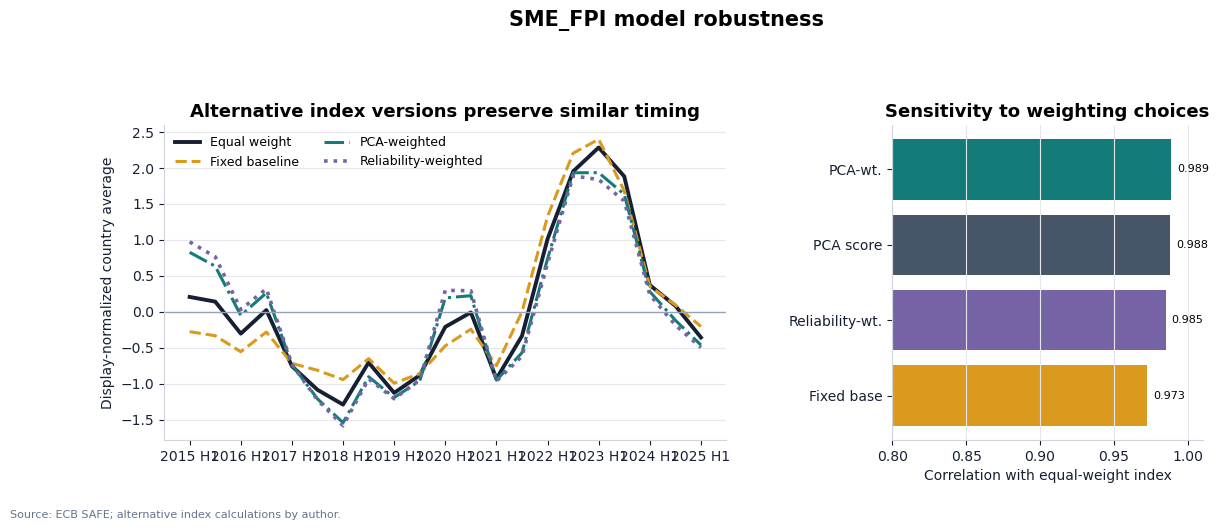

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\03b_index_sensitivity_check.png


In [30]:
plot_index_sensitivity(panel, weights, sensitivity)

**Interpretation and design rationale**

- Chart type: a line chart checks whether alternative index versions tell a similar time-story, while the bar chart summarizes similarity to the transparent equal-weight baseline.
- Design choice: the line chart display-normalizes each country-average index version so the comparison focuses on timing and pattern rather than different scale definitions.
- Result: high correlations with the equal-weight index suggest that the main story is not driven by one arbitrary weighting choice.
- Limitation: fixed-baseline values use a different reference period, so correlation and rank stability are more meaningful than direct level differences.

## External and Forward Validation

This section checks whether SME_FPI is related to outcomes outside the exact six-component index.

The validation targets are:

- future access-to-finance severity from the larger SAFE Q0B cube,
- future severe-response shares from the same big cube,
- a future macro stress context built from World Bank GDP growth, unemployment, inflation, and private-credit variables,
- future CISS as a market-stress benchmark.

These are plausibility checks, not causal proof.

,layer,variable,status,use
0,Core borrower-side SAFE,Current six SME_FPI components,implemented,Baseline and alternative SME_FPI construction
1,Core borrower-side SAFE,Availability/collateral/other cost variables,candidate,Future index expansion if exact SAFE series ar...
2,Big SAFE Q0B cube,Access-to-finance severity and severe-response...,implemented,Validation target and Big Data diagnostic layer
3,Market benchmark,ECB New CISS,implemented,Common euro-area market-stress benchmark
4,Macro context,"GDP growth, unemployment, inflation, private c...",implemented,External macro context and future stress valid...
5,Lender-side validation,ECB Bank Lending Survey credit standards,not implemented,Recommended next validation extension


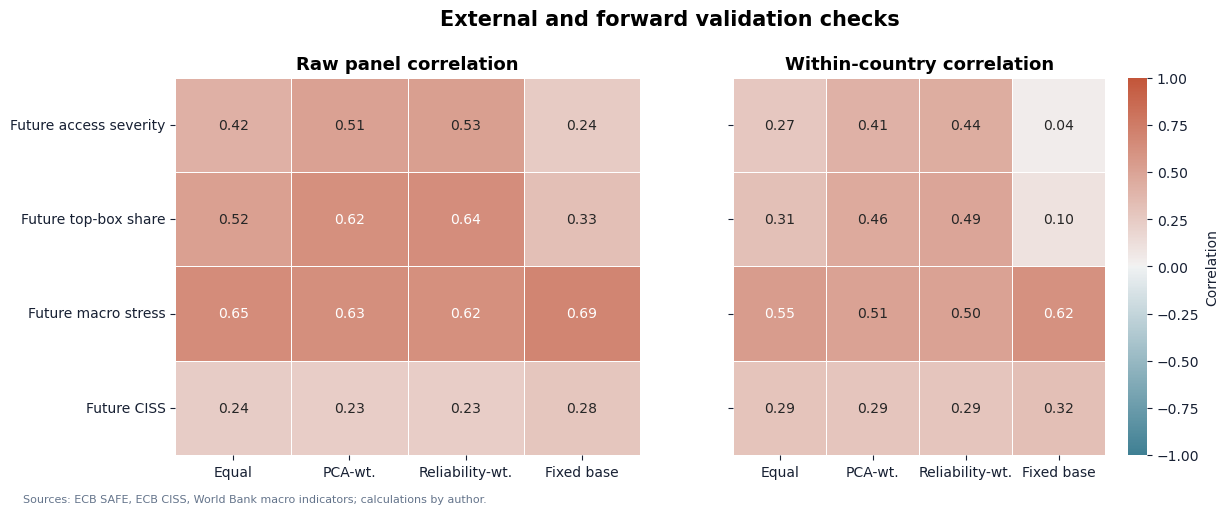

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\03c_external_forward_validation.png


In [31]:
plot_external_validation(validation_results, variable_candidates)

**Interpretation and design rationale**

- Chart type: correlation heatmaps are appropriate because the goal is to compare several index versions against several validation targets.
- Design choice: the first panel shows raw panel correlations; the second removes country-level averages, which reduces the risk that the result is driven only by permanent country differences.
- Result: positive correlations with future access severity and macro stress support the idea that SME_FPI captures meaningful borrower-side pressure.
- Limitation: the macro variables are annual and are aligned to half-year periods, so they should be interpreted as broad context rather than precise high-frequency validation.

## 5. Signature Visualization

This figure summarizes the whole project in one view.

- Top left: how SME_FPI and CISS move over time.
- Bottom left: country-by-period heatmap of SME financing pain.
- Right: latest relative gap between SME_FPI and the common CISS benchmark by country.

Plain-language interpretation: even when financial markets look calmer, SMEs in some countries may still face financing difficulties.

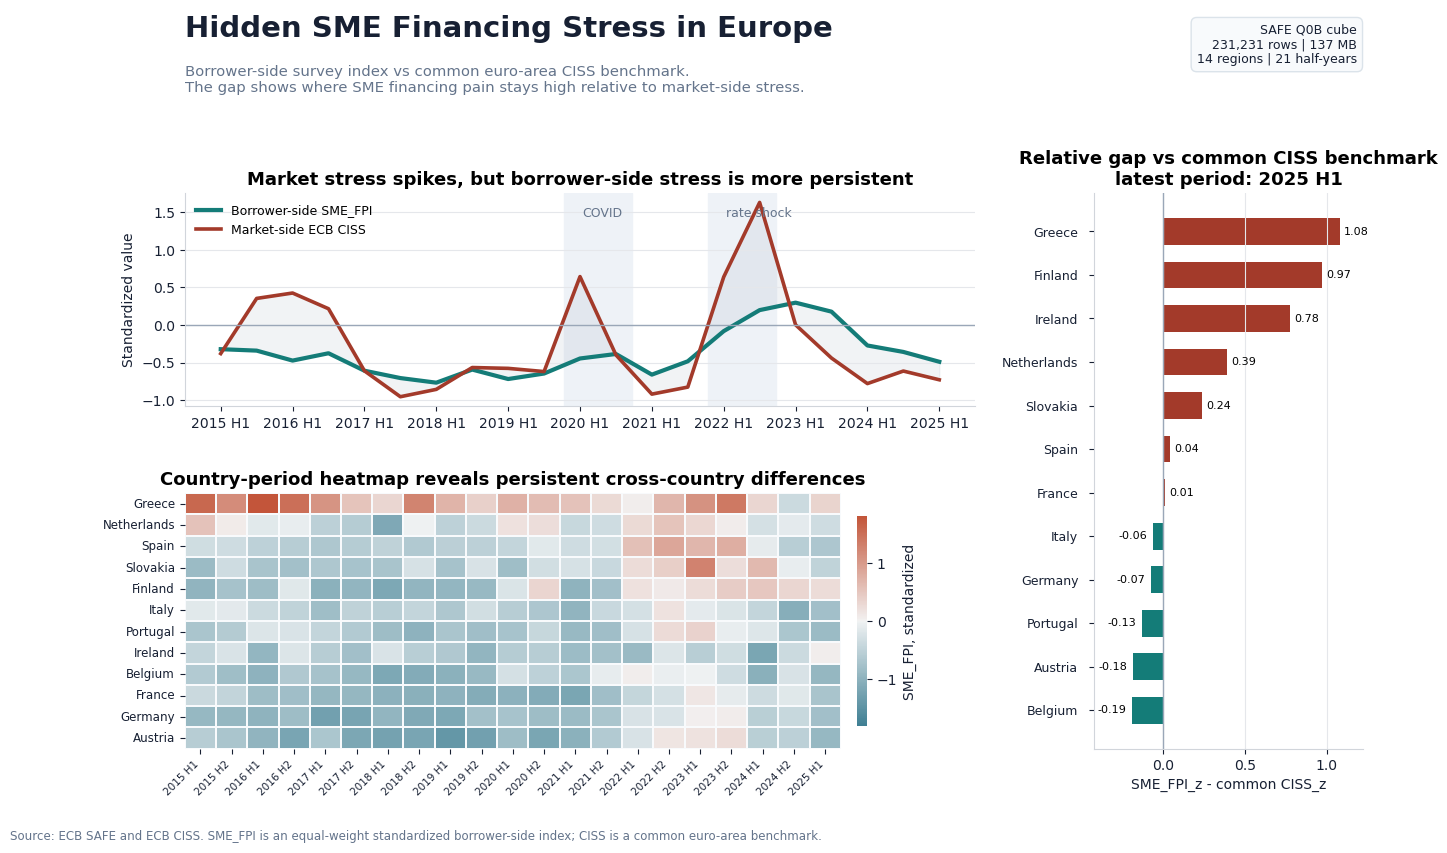

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\00_signature_sme_fpi_story.png


In [32]:
plot_signature(panel, big_review)

**How to read this figure**

- This is an overview figure, not the main evidence by itself.
- The line chart shows the time story; the heatmap shows country-period patterns; the bar chart shows the latest relative gap.
- The layout applies proximity and visual hierarchy: related evidence is grouped together, while the latest-country ranking is separated on the right.
- Main takeaway: SME financing pain can remain visible even when the common market-stress benchmark is lower.

## 6. Borrower-Side Index vs Market-Side Stress

This line chart is used because the variables change over time. If the line moves upward, stress or financing pain is increasing.

The shaded band shows the interquartile range of SME_FPI across countries. This is a cross-country dispersion band, not a statistical confidence interval.

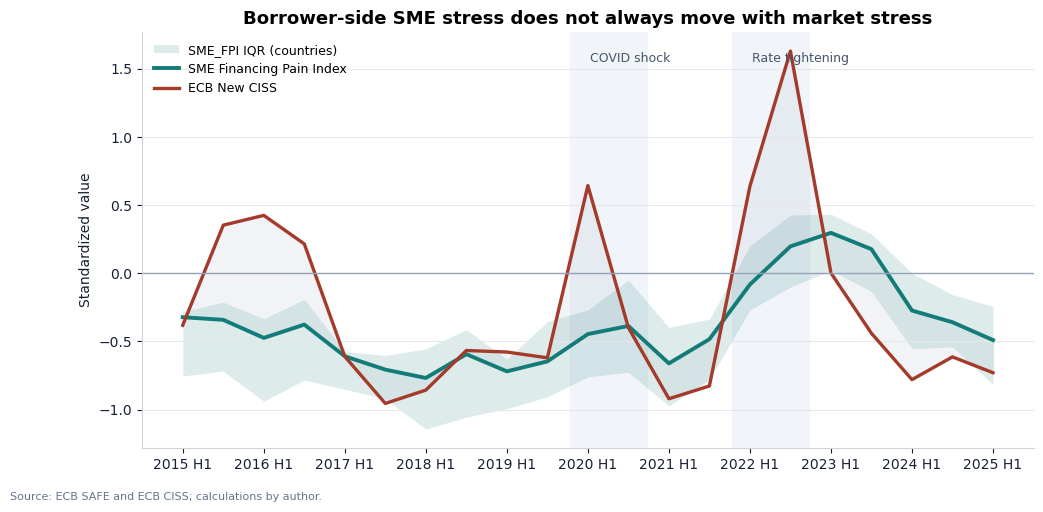

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\01_sme_fpi_vs_ciss_timeseries.png


In [33]:
plot_timeseries(panel)

**Interpretation and design rationale**

- Chart type: a line graph is appropriate because both SME_FPI and CISS change over time.
- Design choice: both series are standardized, so the visual comparison is about relative movement rather than raw units; the shaded band shows cross-country dispersion.
- Result: CISS spikes sharply around market shocks, while SME_FPI changes more gradually and can remain elevated after market stress falls.
- Limitation: CISS is a common euro-area benchmark, so this chart should not be read as country-specific market stress.

## 7. Country-Period Heatmap

A heatmap is useful because it shows countries and time periods at the same time.

- Red means SME financing pain is above average.
- Blue means SME financing pain is below average.

This chart answers: which countries were under stress, and when?

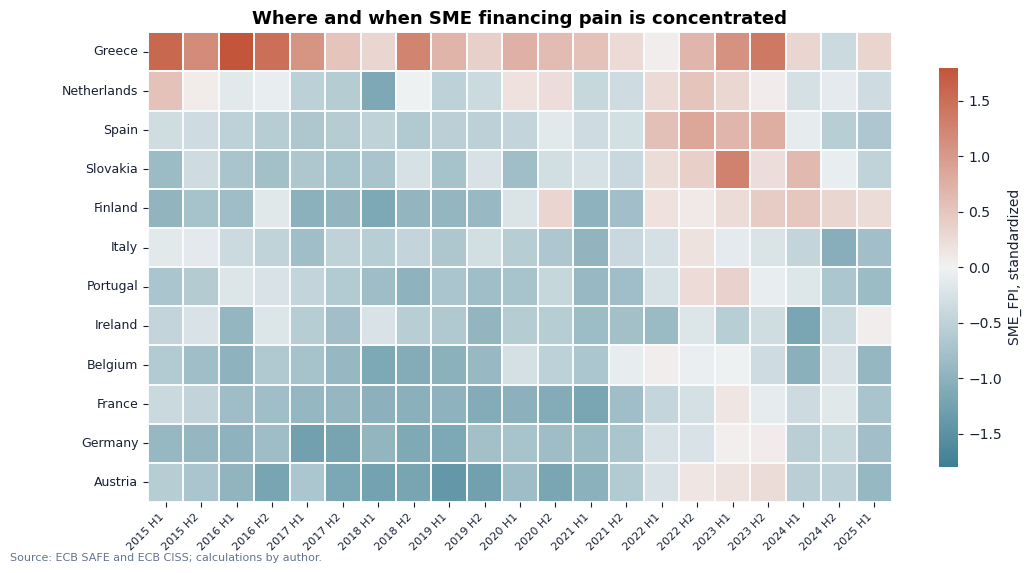

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\02_country_period_heatmap.png


In [34]:
plot_country_heatmap(panel)

**Interpretation and design rationale**

- Chart type: a heatmap is appropriate because the question involves two dimensions at once: countries and half-year periods.
- Design choice: the diverging color scale separates below-average and above-average SME financing pain.
- Result: Greece and some later-period observations show persistent higher stress, while several countries remain below average for long periods.
- Limitation: color gives a strong pattern overview, but exact values should be read from the underlying table or supporting charts.

## 8. Relative SME-CISS Gap

This bar chart shows the latest country-level gap.

If a bar extends to the right, SME financing pain is high relative to the common CISS benchmark.

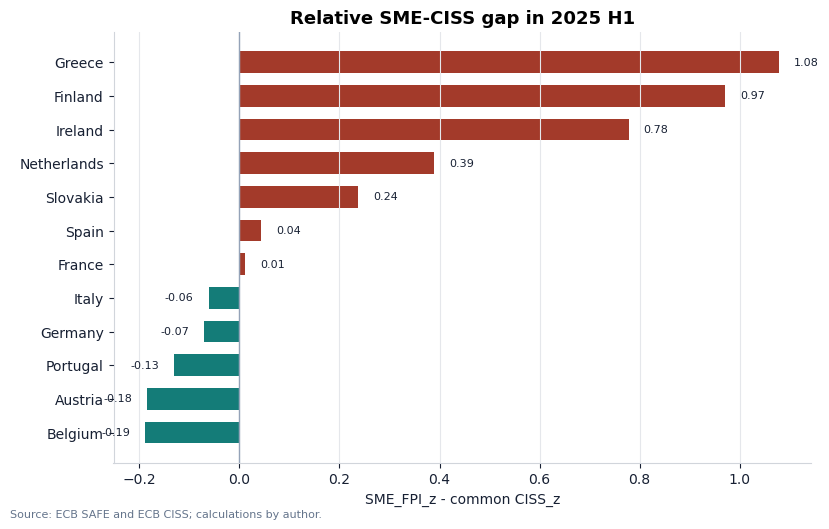

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\03_hidden_sme_stress_gap_latest.png


In [35]:
plot_hidden_gap(panel)

**Interpretation and design rationale**

- Chart type: a horizontal bar chart is appropriate for ranking countries in the latest available period.
- Design choice: the zero line makes positive and negative gaps easy to separate.
- Result: positive bars indicate countries where SME financing pain is high relative to the common CISS benchmark.
- Limitation: this is a relative benchmark gap, not proof that local financial markets caused the stress.

## 9. PCA Loadings

PCA is a method for summarizing several related variables into a smaller number of dimensions. Here, it checks whether the six financing-pain variables point in a consistent direction.

The fact that all PC1 loadings are positive supports the interpretation that these variables measure a common SME financing-pain factor.

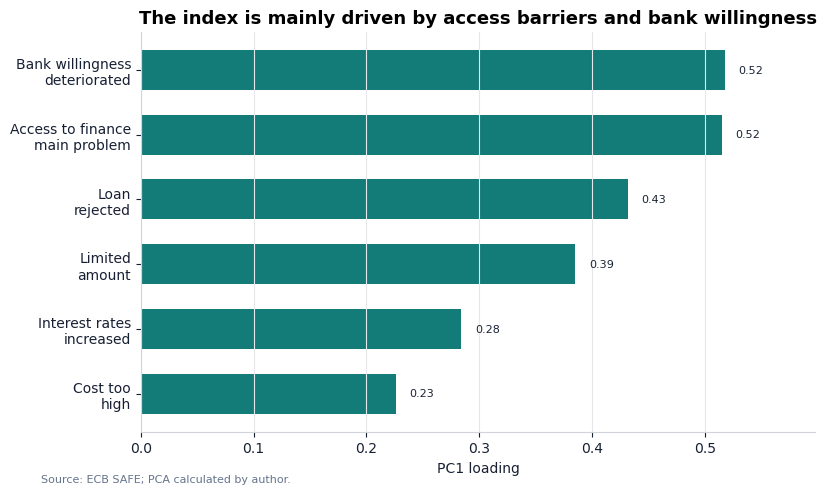

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\04_pca_loadings.png


In [36]:
plot_pca_loadings(loadings)

**Interpretation and design rationale**

- Chart type: a bar chart is appropriate because the goal is to compare component contributions to PC1.
- Design choice: all loadings are shown on the same scale, which avoids exaggerating small differences.
- Result: bank willingness and access-to-finance variables are among the strongest contributors to the common financing-pain dimension.
- MDA relevance: positive PC1 loadings support the idea that the six variables share one broad stress factor.

## 10. PCA Correlation Circle

A PCA correlation circle shows how each original variable relates to the first two principal components.

It helps explain whether the variables point in a similar direction and whether PC2 captures a different type of stress.

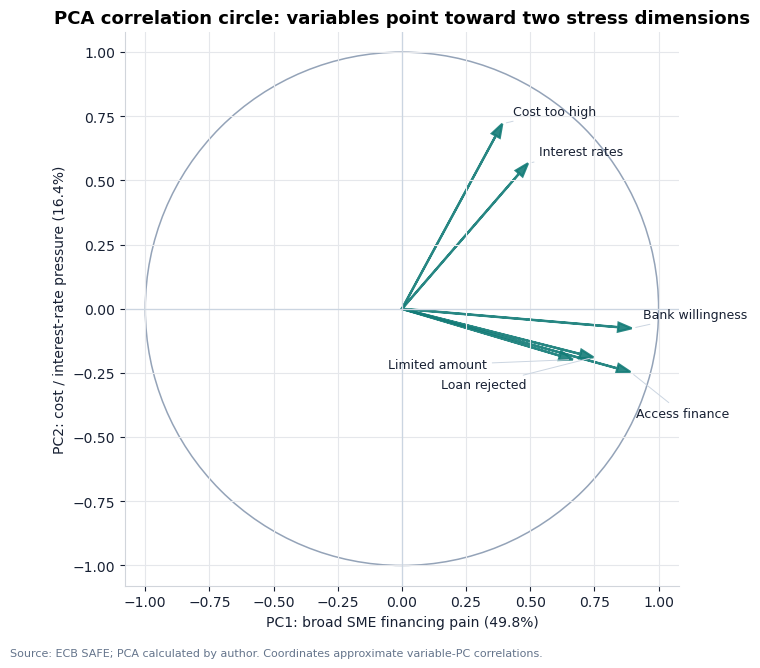

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\04c_pca_correlation_circle.png


In [37]:
plot_pca_correlation_circle(loadings, explained)

**Interpretation and design rationale**

- Chart type: a PCA correlation circle is appropriate for validating the variable structure behind a multidimensional index.
- Design choice: the unit circle helps show whether variables are strongly represented by PC1 and PC2.
- Result: access barriers and bank willingness should mostly define PC1, while cost and interest-rate variables help explain PC2.
- Limitation: the coordinates approximate variable-PC correlations from PCA loadings and explained variance, so this is a validation guide rather than a separate model.

## 11. Correlation Heatmap

This chart shows how strongly the numeric variables move together.

Positive correlations among the financing variables make it more reasonable to combine them into one index. The chart also shows that CISS remains conceptually distinct from the borrower-side variables.

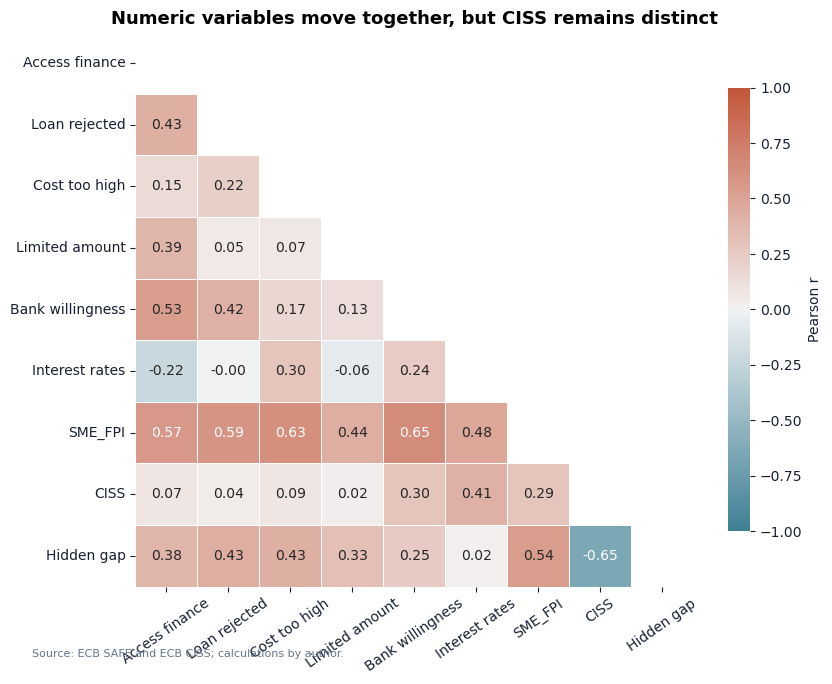

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\04b_numeric_correlation_heatmap.png


In [38]:
plot_correlation(panel)

**Interpretation and design rationale**

- Chart type: a correlation heatmap is appropriate for checking whether numeric variables move together.
- Design choice: the lower triangle avoids repeating the same correlation twice.
- Result: SME_FPI is positively related to several borrower-side financing variables, while CISS is not identical to the borrower-side index.
- Limitation: correlation describes co-movement, not causality.

## 12. PCA Cluster / Financing Regimes

Each point is one country in one half-year period. Points that are close together have similar financing-stress patterns.

KMeans clustering is not used as a forecasting model here. It is used as a descriptive tool to group similar country-period situations. The X markers show cluster centroids.

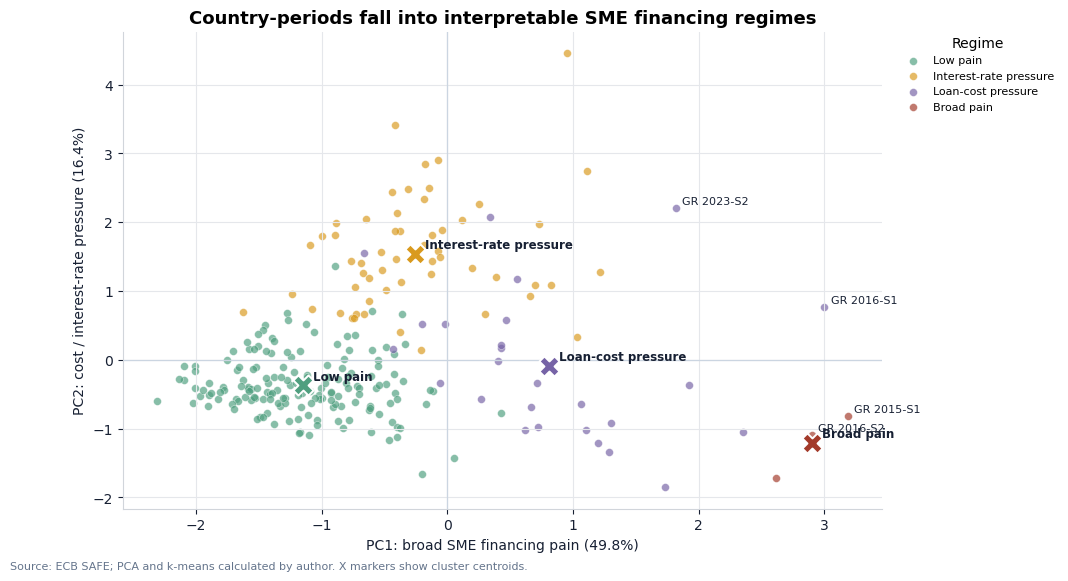

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\05_pca_cluster_regimes.png


In [39]:
plot_clusters(panel, explained)

**Interpretation and design rationale**

- Chart type: a scatterplot is appropriate because PCA creates two numerical dimensions that can be plotted as x and y.
- Design choice: color separates financing regimes, X markers show centroids, and labels are used only for a few extreme observations to avoid clutter.
- Result: broad-stress observations sit far from the low-stress group, suggesting distinct financing regimes.
- MDA relevance: this is the main multidimensional visualization because it combines PCA with clustering.

## 12b. Cluster Count Diagnostic

The main cluster plot uses four regimes because the result is interpretable: low pain, interest-rate pressure, loan-cost pressure, and broad financing pain.

This diagnostic checks whether that choice is at least reasonable by comparing elbow and silhouette scores for several possible cluster counts.

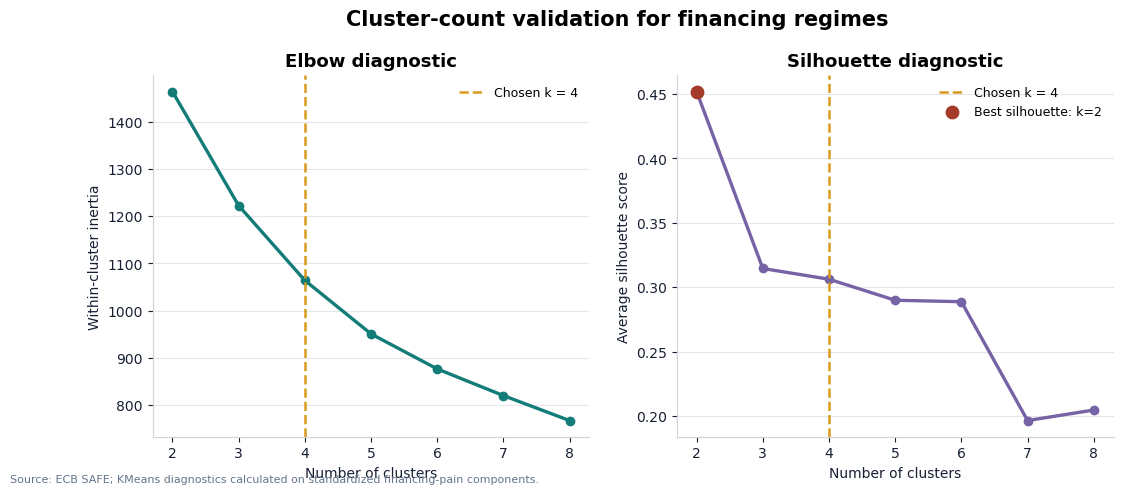

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\05b_cluster_validation_diagnostics.png


In [40]:
plot_cluster_validation(cluster_validation)

**Interpretation and design rationale**

- Chart type: line charts are appropriate because the diagnostics are calculated over ordered values of `k`.
- Design choice: the chosen four-cluster solution is marked with a vertical line so the reader can compare it with alternatives.
- Result: the chart makes the cluster-count choice transparent instead of leaving `k = 4` as an unexplained modeling decision.
- Limitation: elbow and silhouette diagnostics do not choose the cluster count automatically; interpretability still matters for this descriptive project.

## 13. Box & Whisker Plot: Index Distribution by Regime

This box plot checks whether the regime labels are meaningful.

Each dot is one country-period observation. The box summarizes the middle part of the distribution, while the line inside the box shows the median.

Plain-language interpretation: if the boxes are clearly separated, the clusters are not just technical labels; they represent visibly different levels of SME financing pain.

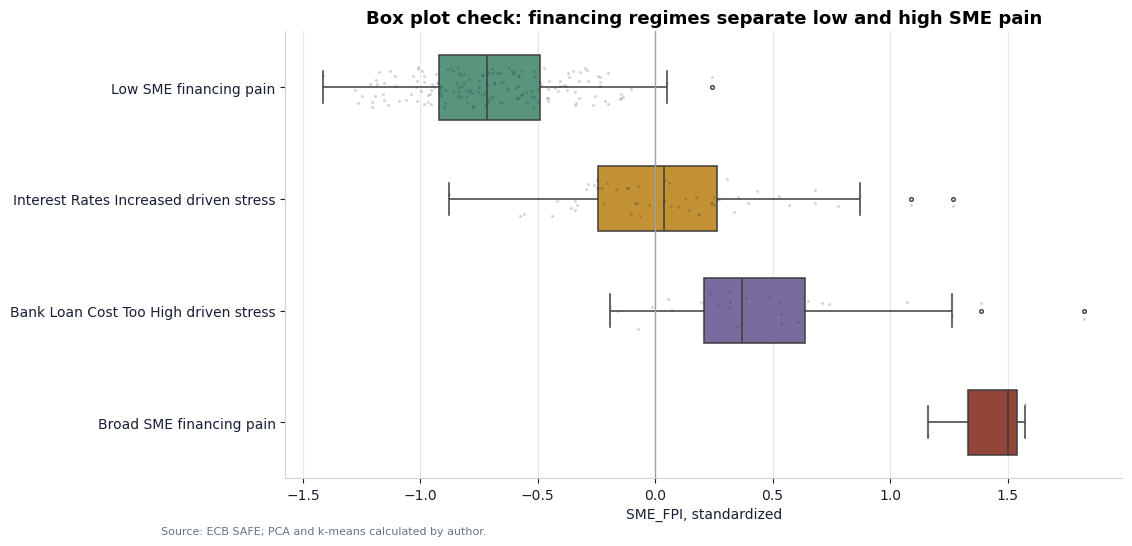

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\12_cluster_boxplot.png


In [41]:
plot_cluster_boxplot(panel)

**Interpretation and design rationale**

- Chart type: a box plot is appropriate for comparing distributions across regime groups.
- Design choice: the individual dots are kept visible so the reader can see that the boxes summarize real country-period observations.
- Result: the broad-stress regime has a clearly higher SME_FPI distribution than the low-pain regime.
- Limitation: regime labels are descriptive clusters, not formal causal categories.

## 14. Parallel Coordinates Plot: Multidimensional Regime Profiles

A parallel coordinates plot is useful when several variables define the same situation.

Here, each line is a financing regime. Each vertical position shows whether that component is above or below its average level.

Plain-language interpretation: the red broad-stress regime is high on several dimensions at once, while the low-pain regime stays below average across most components.

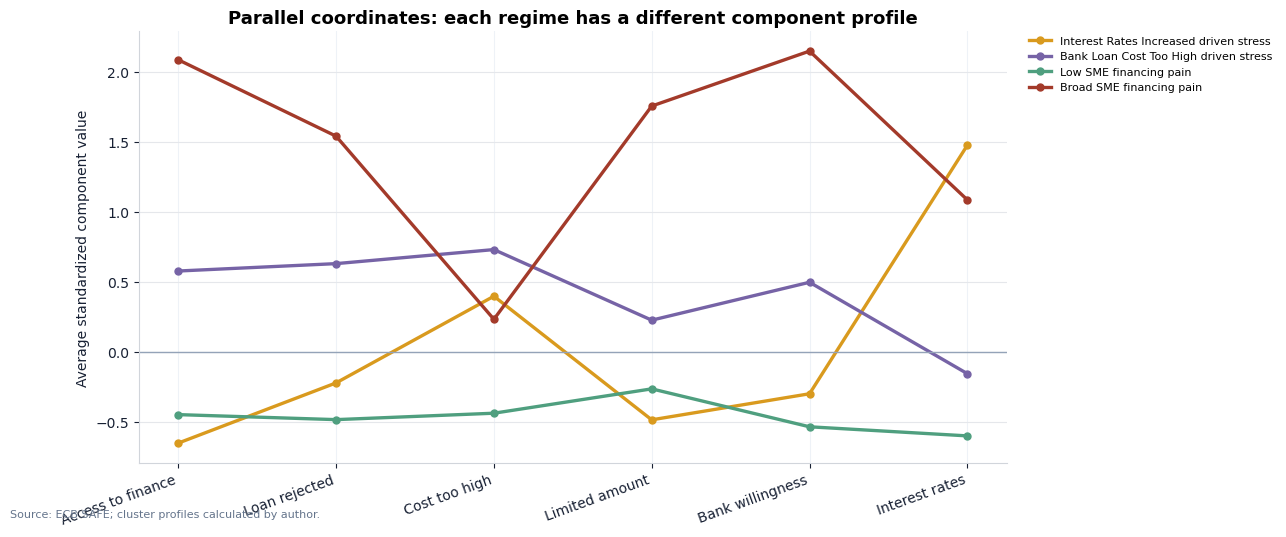

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\13_parallel_coordinates_profiles.png


In [42]:
plot_parallel_cluster_profiles(profiles)

**Interpretation and design rationale**

- Chart type: a parallel coordinates plot is appropriate because each regime is defined by several components at once.
- Design choice: standardized component values allow different variables to be compared on one shared vertical scale.
- Result: the broad-stress regime is high on multiple components, while the interest-rate regime is especially high on interest-rate pressure.
- Limitation: this chart is best for profile comparison, not for reading exact individual-country values.

## 15. Bubble Chart: Borrower Stress vs Market Stress

A bubble chart is useful here because it shows three variables at once.

- X-axis: market-side stress measured by CISS.
- Y-axis: borrower-side SME financing pain measured by SME_FPI.
- Bubble size: size of the gap between the two.

Points above the dashed line are cases where borrower-side SME financing pain is higher than market-side stress.

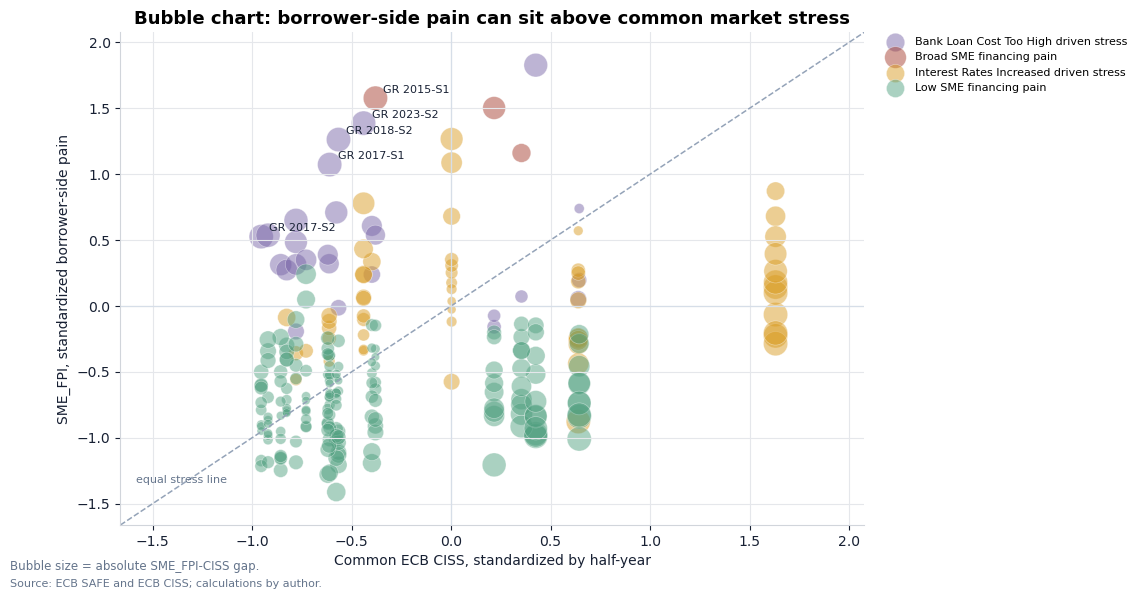

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\14_bubble_sme_fpi_vs_ciss_gap.png


In [43]:
plot_bubble_alignment(panel)

**Interpretation and design rationale**

- Chart type: a bubble chart is appropriate because it shows CISS, SME_FPI, and the size of their gap in one view.
- Design choice: the dashed diagonal line marks equal standardized stress; points above it have higher borrower-side pain than market-side stress.
- Result: several observations sit above the diagonal, supporting the idea that SME stress is not fully captured by CISS.
- Important note: CISS is common by half-year, so vertical bands are expected rather than a plotting error.

## 16. Choropleth Map: Latest Relative SME-CISS Gap

A choropleth map is useful because the question has a geographic part: which European countries show higher borrower-side stress relative to the common CISS benchmark?

The map should be read as a regional overview, not as a precise ranking tool. Large countries take more visual space, so exact values are better read from the bar chart.

In [44]:
plot_choropleth_latest_gap(panel)

Saved interactive choropleth map: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\15_choropleth_latest_hidden_gap.html


**Interpretation and design rationale**

- Chart type: a choropleth map is appropriate because the latest gap has a geographic interpretation.
- Design choice: a diverging color scale separates positive and negative gaps around zero.
- Result: the map gives a quick regional overview of where borrower-side stress is higher or lower relative to CISS.
- Limitation: country size affects visual attention, so the bar chart is better for precise ranking.

## 17. Why I Did Not Add a Treemap

A treemap is best for part-to-whole data, for example how a total budget is divided across categories.

The SAFE severity variables in this project are not clean parts of one total. They are separate survey ratings across problem types, firm sizes, countries, and periods. Using a treemap could wrongly imply that the categories add up to one meaningful whole, so it is better not to use it here.

## 18. Firm-Size Component Heatmap

This heatmap shows which financing-pain components are more visible for different firm sizes.

SMEs are not all the same. Micro, small, medium, and large firms can face different types of financing pressure.

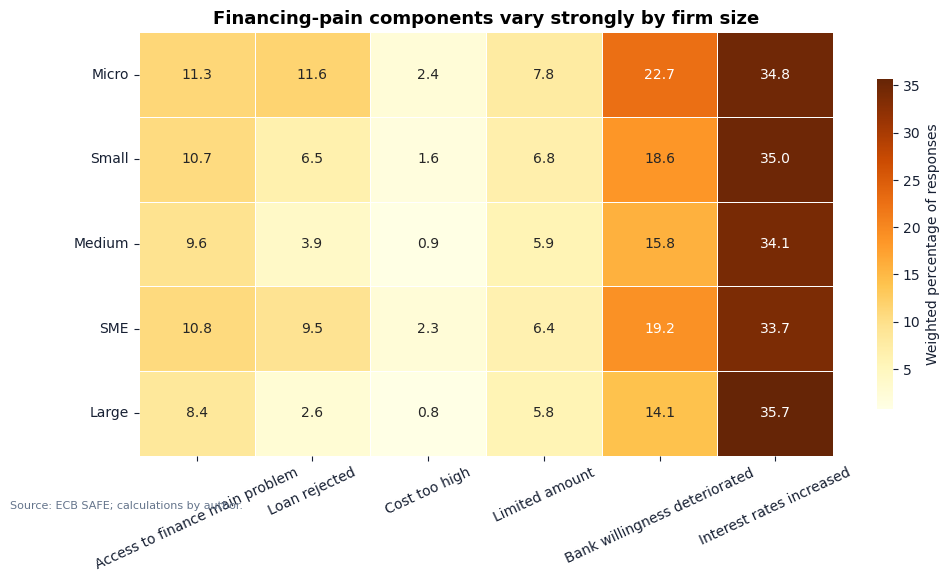

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\06_firm_size_component_heatmap.png


In [45]:
plot_size_component(size_summary)

**Interpretation and design rationale**

- Chart type: a heatmap is appropriate because it compares firm sizes across several financing-pain components.
- Design choice: direct numeric labels reduce ambiguity in the color scale.
- Result: micro and small firms often show higher access-to-finance pressure than larger firms.
- Limitation: this is a firm-size breakdown, not a full causal explanation of why smaller firms face more pressure.

## 19. General-Audience Redesign

This figure demonstrates how a complex line chart can be redesigned for a general audience.

The left side gives all lines equal visual weight, which makes the chart hard to read. The right side highlights the average and the most relevant countries, making the message clearer.

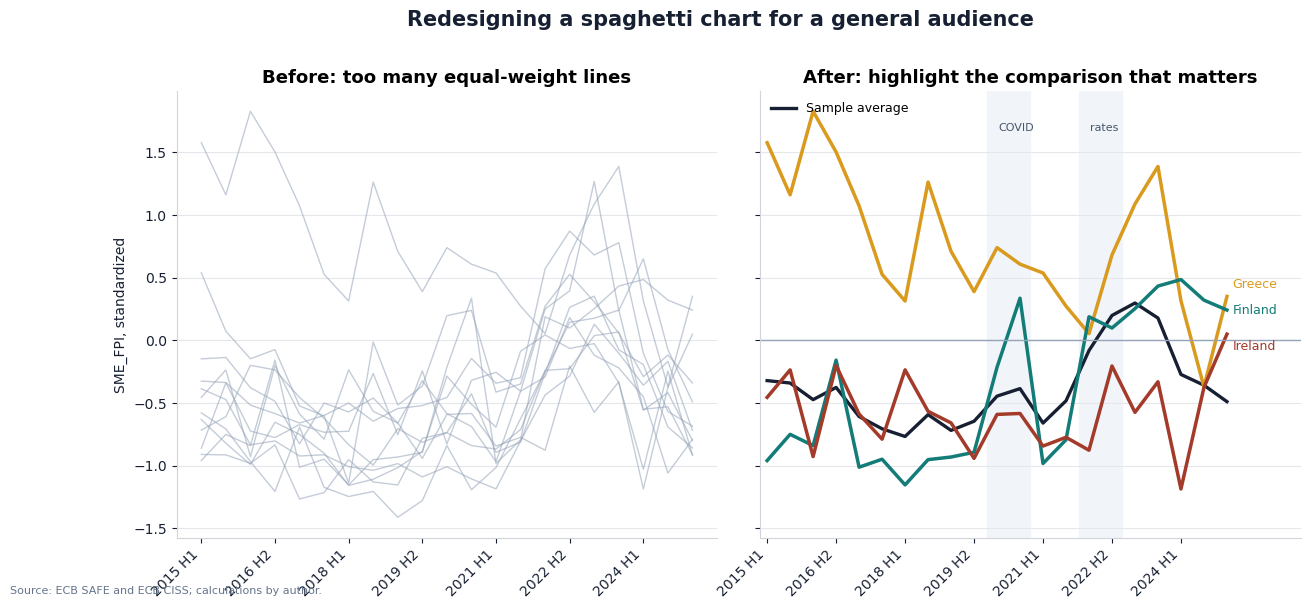

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\08_general_audience_redesign.png


In [46]:
plot_redesign(panel)

**Interpretation and design rationale**

- Chart type: this is a before-and-after redesign of a multi-line time series.
- Design choice: the redesigned version uses selective emphasis, direct labels, and muted background lines to reduce cognitive load.
- Result: the reader can focus on the average and the most relevant countries instead of trying to decode every line.
- Course concept: this applies Gestalt principles of similarity, contrast, and figure-ground separation.

## 20. Big Data Cube: Problem Severity by Firm Size

From this point onward, the notebook directly uses the 231,231-row SAFE Q0B big cube.

The severity score is a descriptive weighted average of 1-to-10 survey response levels. It shows how serious firms perceive each problem to be, but it should not be interpreted as an exact physical measurement.

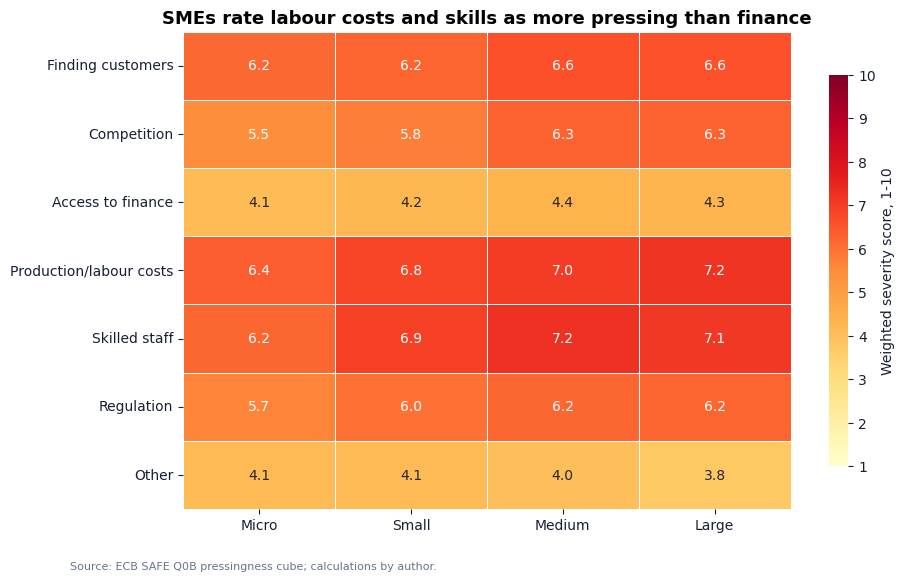

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\09_big_cube_problem_severity_by_size.png


In [47]:
plot_big_cube_problem(severity_cube)

**Interpretation and design rationale**

- Chart type: a heatmap is appropriate because the big cube compares problem categories across firm sizes.
- Design choice: the 1-to-10 severity scale is shown with direct labels, making the ordinal score easier to read.
- Result: labour costs and skilled staff are generally rated as more pressing than access to finance in the latest view.
- Big Data relevance: this figure uses the larger 231,231-row SAFE Q0B cube, not only the compact 386-row panel.

## 21. Big Data Cube Robustness: Severe-Response Shares

The previous heatmap uses a weighted mean of 1-to-10 survey answers. That is useful, but it treats the answer scale as if each step has the same distance.

This robustness figure checks the same story using response shares instead:

- **Top-box share:** the share of valid responses rated 8, 9, or 10.
- **High-pressure share:** the share of valid responses rated 7, 8, 9, or 10.

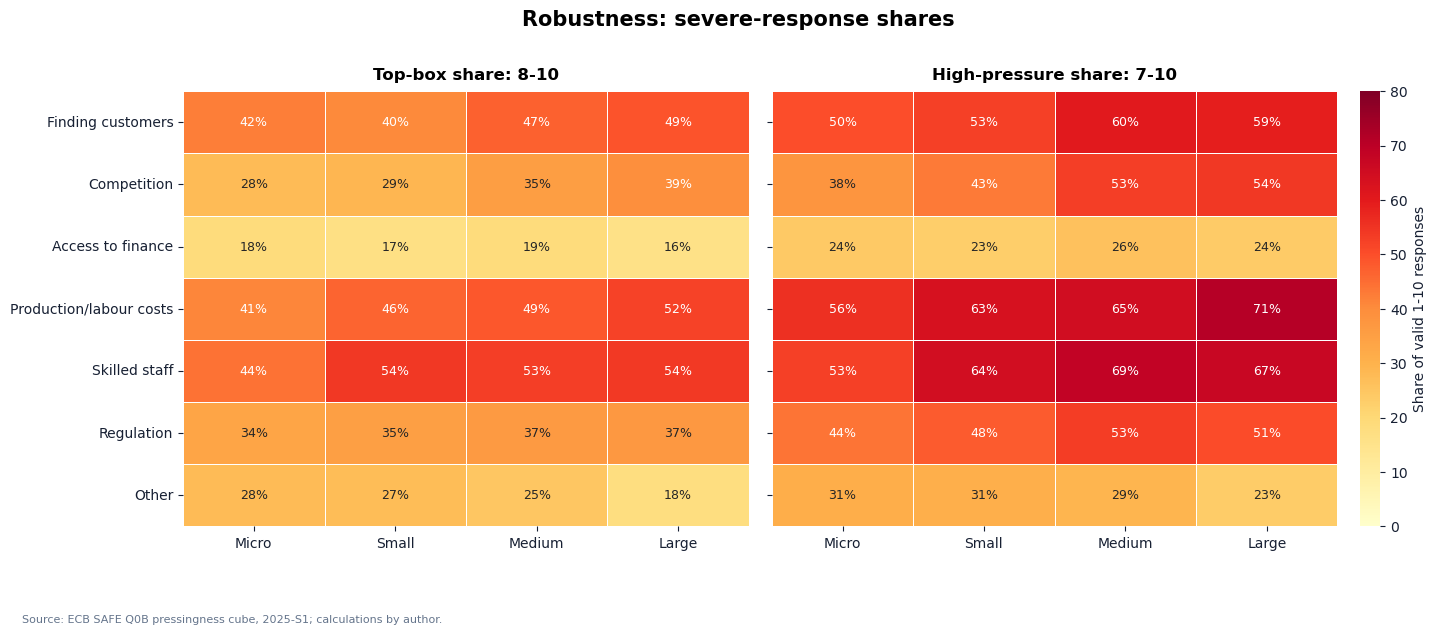

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\09b_big_cube_topbox_highpressure.png


In [48]:
plot_big_cube_robustness(severity_cube)

**Interpretation and design rationale**

- Chart type: side-by-side heatmaps are appropriate because the same problem-by-firm-size structure is compared across two related robustness measures.
- Design choice: both panels use the same sequential color scale, so color intensity can be compared directly.
- Result: the severe-response shares check whether the main big-cube conclusion depends only on the weighted mean severity score.
- Methodological value: this is safer for ordinal survey data because it counts high-pressure responses instead of relying only on exact distances between 1 and 10.

## 22. Big Data Cube: Access-to-Finance Breakdowns

This figure shows how access-to-finance concern differs by firm size and by sector.

The data do not provide a complete firm-size by sector cross-tab for this view, so the chart presents honest marginal breakdowns instead of fabricating a two-way matrix.

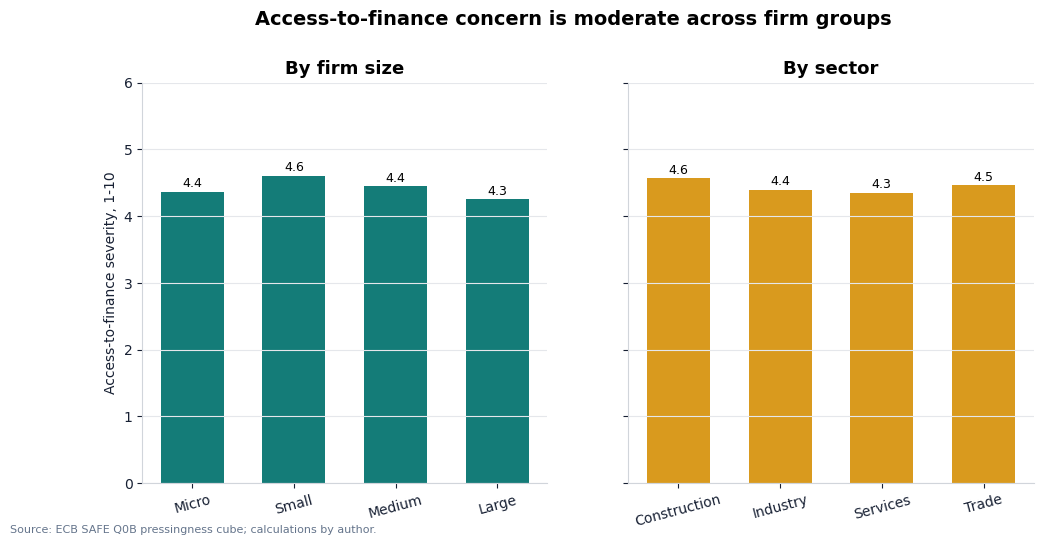

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\10_access_finance_severity_marginal_breakdowns.png


In [49]:
plot_marginal_breakdowns(access_cube)

**Interpretation and design rationale**

- Chart type: grouped bar charts are appropriate for comparing simple averages by firm size and sector.
- Design choice: the two panels are separated because the data support marginal breakdowns, not a complete firm-size-by-sector matrix.
- Result: access-to-finance severity is moderate and fairly close across groups.
- Limitation: the small differences should be interpreted cautiously because they are descriptive survey summaries.

## 23. Big Data Cube: Access-to-Finance Trend

This line chart shows how the severity of access-to-finance problems changed after 2015.

Thin gray lines show individual country trends, while the thick teal line shows the country average.

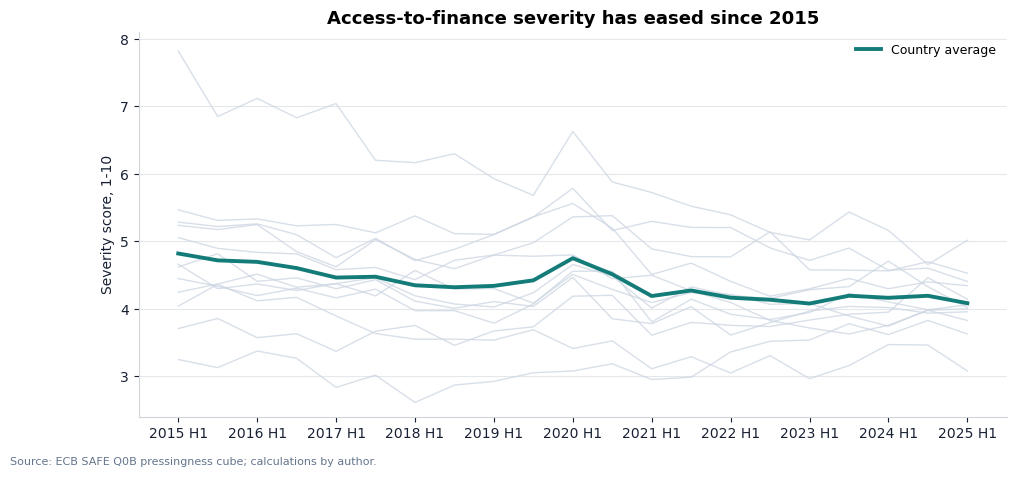

Saved notebook-generated figure: C:\Users\Jun\Desktop\Kozminski\Big Data Visualization and Analysis\SME_FPI\figures\notebook_generated\11_access_finance_severity_big_cube_trend.png


In [50]:
plot_big_cube_trend(access_cube)

**Interpretation and design rationale**

- Chart type: a line graph is appropriate because the severity score changes over half-year periods.
- Design choice: thin gray country lines show variation, while the thick teal line gives the overall pattern.
- Result: access-to-finance severity has generally eased since 2015, with temporary bumps around stress periods.
- Limitation: the severity score is a pragmatic weighted mean of ordinal survey answers, so it is descriptive rather than a precise physical measure.

## 24. Automated Profiling Report

Finally, `ydata_profiling` creates an automated EDA report for the main analytical panel. The HTML report helps inspect variable types, missing values, distributions, and correlations.

In [51]:
# Install the profiling package in the active Jupyter kernel.
%pip install ydata_profiling --quiet

Note: you may need to restart the kernel to use updated packages.


In [52]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Profiling Report", minimal=True, explorative=True)
profile_path = REPORTS / "sme_fpi_ydata_profile.html"
profile.to_file(str(profile_path))
HTML(f"<a href='{profile_path.as_posix()}'>Open ydata profiling report</a>")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 44/44 [00:00<00:00, 1135.82it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]